# Safe Trajectory Gradient Flow

*Trager Joswig-Jones, Spring 2025*

This notebook contains the code used to generate the results in the paper ["Safe Trajectory Gradient Flow Control of a Grid-Interfacing Inverter" by Trager Joswig-Jones and Baosen Zhang](https://github.com/TragerJoswig-Jones/Safe-Trajectory-Gradient-Flow).

## Imports and Function Definitions

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sympy import *
import sympy as sym
from sympy.physics.vector import dynamicsymbols
from scipy.optimize import fsolve
import time

import cvxpy as cp

try:
  from casadi import *
except:
  !pip install casadi
  from casadi import *

In [2]:
from matplotlib import patheffects

def plot_2d_constraints(gx, x, y_domain=[-1,1], x_domain=[-1,1], n_points=100, inequality=True, alpha=1.):
  for gx_i in gx:
    gx_x2 = sym.solve(gx_i, x[1])
    f_gx_x2 = lambdify(x[0], gx_x2)
    x1_range = np.linspace(*x_domain, n_points)

    # lambdify expression
    f_gx_i = lambdify((x[0], x[1]), gx_i)

    # Set up survey vectors
    nx = 100
    ny = 100
    xvec = np.linspace(*x_domain, nx)
    yvec = np.linspace(*y_domain, ny)

    # Set up survey matrices.  Design disk loading and gear ratio.
    x1, x2 = np.meshgrid(xvec, yvec)

    cg2 = plt.contour(x1, x2, f_gx_i(x1, x2), [0], colors='C7', alpha=alpha)
    if inequality:
      cg2.set(path_effects=[patheffects.withTickedStroke(angle=60, length=2)])

  return cg2

    #plt.plot(x1_range, f_gx_x2(x1_range)[0], color='C7')

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset, inset_axes

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update({
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 9,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,

    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.color': '0.85',
    'grid.linewidth': 0.8,
})

import seaborn as sns

# Color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=sns.color_palette("colorblind"))

## Safe Gradient Flow

The following notes in this section are based on **["Anytime Solution of Constrained Nonlinear Programs via Control Barrier Functions" by Ahmed Allibhoy, Jorge Cortés](https://ieeexplore.ieee.org/document/9683035/)**

Given a nonlinear program of the form
\begin{align*}
\min_{x} \quad & c(x) \\
\textrm{s.t.} \quad & g(x) \geq 0 \\
& h(x) = 0
\end{align*}

Denote the feasible set as $\mathcal{C} = \{ x \in \mathcal{E}^n | g(x) \leq 0, h(x) = 0 \}$.

We want to design a locally Lipschitz-continous vector field $F: \mathbb{R}^n \to \mathbb{R}$, such that the feasible set $\mathcal{C}$ is forward invariant and all trajectories converge to locally optimal points $X_\mathrm{KKT}$.

**Idea:** Solve this problem with inspiration from control barrier functions.

Consider the control-affine system
$$
\dot{x} = -\nabla_x c(x) - \frac{\partial g(x)}{\partial x}^\top u - \frac{\partial h(x)}{\partial x}^\top v,
$$
where $x \in \mathbb{R}^n$ is the state, and $u \in \mathbb{R}^l, v \in \mathbb{R}^k$ are inputs.

Here the gradient of $c$ minimizes the cost function, while the additional inputs are used to ensure that the feasible set $\mathcal{C}$ remains safe.

Recall the definition of a control barrier function. A function $b$ is a control barrier function (CBF) if
$$
\exists \alpha : \sup_{u} (\nabla_x b \cdot f + \nabla_x b \cdot g \cdot u) \geq -\alpha(B(x)),
$$
where $\alpha$ is an extended class $\kappa$ function.

If $b$ is a CBF and $\nabla b(x) \ne 0$ for $x \in \partial \mathcal{C}$ then any $u: \mathbb{R}^n \to \mathbb{R}^m$
satisfying $u(x) \in \{\mu: \dot{b} + \alpha(b(x)) \geq 0\}$ renders $\mathcal{C}$ safe.

https://github.com/sburden/546-25sp-opt-lrn/blob/main/lec-20-control-barrier-functions.pdf

Applying CBF theory here, the admissable control set that ensures $\mathcal{C}$ is invariant is
\begin{align*}
K(x) = & \{(u,v) \hspace{0.5em}| \\ &
- \frac{\partial g}{\partial x} \frac{\partial g}{\partial x}^\top u - \frac{\partial g}{\partial x} \frac{\partial h}{\partial x}^\top v \leq \frac{\partial g}{\partial x} \nabla c(x) - \alpha(g(x)) \\ &
- \frac{\partial h}{\partial x} \frac{\partial g}{\partial x}^\top u - \frac{\partial h}{\partial x} \frac{\partial h}{\partial x}^\top v = \frac{\partial h}{\partial x} \nabla c(x) - \alpha(h(x))  \}
\end{align*}

Then the feedback controller is synthesized as the quadratic program
$$
(u(x), v(x)) = \underset{u,v \in K(x)}{\mathrm{argmin}} \left \{ \left\| \frac{\partial g(x)}{\partial x}^\top u + \frac{\partial h(x)}{\partial x}^\top v \right\|^2 \right\}
$$
This feedback controller finds the minimum alternation to the gradient descent required to maintain safety.

### Define a SGF solver class

In [4]:
class sgf_solver():
  def __init__(self, x, fx, gx, hx, alpha, a, args=[], alpha_args=[], verbose=False, solver=cp.CLARABEL):
    """
    x: SymPy state matrix, x
    f: SymPy objective function, min f(x)
    gx: SymPy inequality constraints, g(x) >= 0
    hx: SymPy equality constraints, h(x) == 0
    alpha: K-class function for cbf formulation, must be defined in terms of a
    a: alpha(a) placeholder input variable (define as a sym.symbol or sym.Wild)
    args: Additional arguments that one or more of the expressions contains
    """

    self.n = x.shape[0] # number of states
    self.m = gx.shape[0] # number of inequality constraints
    self.k = hx.shape[0] # number of equality constraints

    self.verbose = verbose
    self.solver = solver

    self.f_args = args  # f(x), g(x), h(x) parameters
    self.alpha_args = alpha_args  # class-K function parameters

    self.eps = 1e-4

    self.define_opt()
    self.define_parameter_functions(x, fx, gx, hx, alpha, a, args, alpha_args)
    print("Solver initialized!") if self.verbose else None

  def define_parameter_functions(self, x, fx, gx, hx, alpha, a, args=[], alpha_args=[]):
    print("Differentiating f(x)...") if self.verbose else None
    dfx = Matrix([fx]).jacobian(x).T
    print("Differentiating g(x)...") if self.verbose else None
    dgx = gx.jacobian(x)
    print("Differentiating h(x)...") if self.verbose else None
    dhx = hx.jacobian(x)

    print("Generating parameter functions...") if self.verbose else None

    alphaf = sym.Function(r'\alpha')  # symbolic function placeholder

    self.df = lambdify((*x,*args,*alpha_args), dfx, 'numpy')

    Gx = dgx @ dgx.T
    GHx = dgx @ dhx.T
    Hx = dhx @ dhx.T
    bgx = (dgx @ dfx - gx.applyfunc(alphaf).replace(alphaf(a), alpha))   # Can use exponential alpha function to enforce constraints strictly when violated,
    bhx = (dhx @ dfx - hx.applyfunc(alphaf).replace(alphaf(a), alpha))   # but allow internal barrier force to be significant enough to stear state early.

    self.param_expr = [Gx, GHx, Hx, bgx, bhx, dgx, dhx]

    # Trying to speed up lambdify operation
    def make_func(flat_lambda, shape):
      # Function generator
      def f(fargs):
          return np.array(flat_lambda(*fargs), dtype=float).reshape(shape)
      return f

    param_f_dict_data = []
    self.flat_lambdas = []
    for param, expr in zip(self.params, self.param_expr):
      shape = expr.shape
      flat = tuple(expr)
      flat_lambda = lambdify((*x, *args, *alpha_args), flat, 'numpy')
      f_lambda = make_func(flat_lambda, shape)
      param_f_dict_data.append((param, f_lambda))
    self.param_f = dict(param_f_dict_data)

  def define_opt(self):
    print("Defining optimization problem...") if self.verbose else None

    # Define the CVXPY problem.
    Dg = cp.Parameter((self.m,self.n), name='Dg')
    Dh = cp.Parameter((self.k,self.n), name='Dh')

    # G =  Dg @ Dg.T  # Unfortunately, not recognized as PSD or DPP by CVXPY
    # H =  Dh @ Dh.T
    # GH = Dg @ Dh.T
    G = cp.Parameter((self.m, self.m), name='G', PSD=True)  # These should be PSD, but due to numerical errors sometimes may not be
    H = cp.Parameter((self.k, self.k), name='H', PSD=True)  # We require PSD to use quad_form objective
    GH = cp.Parameter((self.m, self.k), name='GH')

    bg = cp.Parameter((self.m,1), name='bg')
    bh = cp.Parameter((self.k,1), name='bh')

    u = cp.Variable((self.m,1), name='u') #,pos=True)  #TODO: Determine if this must be restricted to positive values
    v = cp.Variable((self.k,1), name='v')

    obj = cp.norm(Dg.T @ u + Dh.T @ v)
    if self.solver == cp.OSQP:
        obj = (1/2)*(cp.quad_form(u, G) + cp.quad_form(v, H))
        # obj = 1/2 * (cp.sum_squares(Dg.T @ u) + cp.sum_squares(Dh.T @ v))

        # A = cp.Parameter((m+k, m+k), name='A', PSD=True) #cp.hstack([Dg.T, Dh.T]).T @ cp.hstack([Dg.T, Dh.T])
        # z = cp.vstack([u, v])
        # obj = (1/2)*(cp.quad_form(z, A))

        # obj = 1/2 * cp.sum_squares(Dg.T @ u + Dh.T @ v)

    constr = [-G @ u - GH @ v <= bg,
          -GH.T @ u - H @ v == bh,]
    params = [G, GH, H, bg, bh, Dg, Dh]
    vars = [u, v]
    prob = cp.Problem(cp.Minimize(obj), constr)
    self.vars = [u, v]
    self.params = params
    self.prob = prob
    self.obj = obj
    self.constr = constr

  def set_params(self, x, args=[], alpha_args=[]):
    for param, f in self.param_f.items():
      value = f([*x.flatten(), *args, *alpha_args])
      if value.shape != param.shape:
        raise ValueError(f"Parameter value does not match parameter shape: {value.shape}. The parameter has shape {param.shape}.")
      try:
        param.value = value
      except ValueError():  # Sometimes x.T @ x is not PSD due to precision errors
        param.value = value + 1e-5 * np.eye(*value.shape)  # Modify the matrix slightly to ensure PSD

  def step(self, x, eta=1e-3, args=[], alpha_args=[], solver_opts={}):
    """
    x: trajectory values
    nu: gradient descent step size
    alpha: control barrier function alpha term
    args: lambda function arguments
    alpha_args: lambda function arguments relating to alpha function
    solver_opts: QP optimization problem solver options
    """
    self.set_params(x, args, alpha_args)
    self.prob.solve(solver=self.solver, verbose=self.verbose, **solver_opts)
    if self.prob.status in ["infeasible", "unbounded"]:
      raise ValueError("Problem is %s..." % self.prob.status)
    u, v = self.vars
    G, GH, H, bg, bh, Dg, Dh = self.params

    gradient = self.df(*x.flatten(), *args, *alpha_args)
    ineq_correction = self.param_f[Dg]([*x.flatten(), *args, *alpha_args]).T @ u.value
    eq_correction = self.param_f[Dh]([*x.flatten(), *args, *alpha_args]).T @ v.value

    xdot = -gradient - ineq_correction - eq_correction
    return x + xdot*eta


## Extension to Dynamical System

We now seek to extend this approach to work with a given discrete time control-affine system
$$
x^+ = f(x) + g(x) u.
$$
Our goal is to formulate a controller that drives the states of this system to a locally optimal point of a given optimization problem
\begin{align*}
\min_{x} \quad & c(x) \\
\textrm{s.t.} \quad & g(x) \leq 0 \\
& h(x) = 0
\end{align*}


**Idea:** Formulate a new trajectory optimization problem.

\begin{align*}
\min_{x, u} \quad & \sum_{\tau=t}^{t+T} c(x_\tau, u_\tau) \\
\textrm{s.t.} \quad & g(x_{\tau}) \leq 0 \hspace{0.5em} \forall \hspace{0.5em} \tau \in (t, t+T] \\
& h(x_\tau) = 0 \hspace{0.5em} \forall \hspace{0.5em} \tau \in (t, t+T] \\
& x_{\tau + 1} = f(x_{\tau}) + g(x_{\tau}) u_\tau \hspace{0.5em} \forall \hspace{0.5em} \tau \in (t, t+T-1]
\end{align*}
where $T$ is the horizon of the trajectory being optimized, and $x \in \mathbb{R}^{n \times T}, u \in \mathbb{R}^{m \times T}$.

Now we denote
$$G(w) = \begin{bmatrix}
g(x_{t}) \\
\vdots \\
g(x_{t+T})
\end{bmatrix}
, H(w) =
\begin{bmatrix}
h(x_{t}) \\
\vdots \\
h(x_{t+T}) \\
x_{t + 1} = f(x_{t}) + g(x_{t}) u_t \\
\vdots \\
x_{t + T} = f(x_{t + T - 1}) + g(x_{t + T - 1}) u_{t + T - 1} \\
\end{bmatrix},
$$
where $w = \begin{bmatrix} x \\ u \end{bmatrix}$.

With this notation we can fit this into the form of our original nonlinear program as
\begin{align*}
\min_{w} \quad & \sum_{\tau = t}^{t+T} c(w_\tau) \\
\textrm{s.t.} \quad & G(w) \geq 0 \\
& H(w) = 0
\end{align*}


We consider a similar affine system as before
$$
\dot{w} = -D_w c(w) - \frac{\partial g(w)}{\partial w}^\top u - \frac{\partial h(w)}{\partial w}^\top v,
$$

Each step of this control system brings $w$ towards a locally optimal point. However, we want implement this controller in real time so we may only be able to update $w$ a few times before a new control action needs to be applied.

Therefore we take inspiratin from model predictive control (MPC), and roll forward in our time horizon every time we update our control action. That is to say we apply control action $u_t$, then roll our states and control actions forward one timestep for the next set of optimizing updates to $w$. While this does not guarentee that we achieve an optimal control trajectory, it will continue to improve future control actions until they become the current control action $u_t$.

In [5]:
# Define the states and inputs
n = 2
x = MatrixSymbol('x', n, 1)

m = 1
u = MatrixSymbol('u', m, 1)

# Define the cost function
Jx = (x[0] - 2)**2 + (x[1] - 0)**2
dJx = Matrix([Jx]).jacobian(x).T

J = lambdify(x, Jx)
dJ = lambdify(x, dJx)
Jx

(x[0, 0] - 2)**2 + x[1, 0]**2

In [6]:
# Define the state dynamics
fx = Matrix([[0, 1], [0, 0]]) @ x + Matrix([[0], [1]]) * u
f = lambdify((x, u), fx, modules="numpy")
fx

Matrix([
[0],
[1]])*u + Matrix([
[0, 1],
[0, 0]])*x

In [7]:
# Define the discretized dynamics and trajectory optimization problem
delta = symbols(r'\Delta')  # time step
fxt = x + delta*fx  # forward euler discretization

T = 20 # 10  # >= r = 2
xt = MatrixSymbol('x', n, T)
ut = MatrixSymbol('u', m, T-1)

Jx_T = 0
for i in range(T):
  Jx_T += Jx.subs(zip(Matrix(x), Matrix(xt[:, i])))

x0_param = MatrixSymbol('x_0', n, 1)
xt_constr = [Matrix(xt[:, 0]) - Matrix(x0_param)]  # Fixes x0 value in each iteration
for i in range(T-1):
  xt_constr.append(Matrix(xt[:, i+1]) - Matrix(fxt).subs(zip(Matrix(x), Matrix(xt[:, i]))).subs(zip(Matrix(u), Matrix(ut[:, i]))))

Xt = Matrix(np.array(xt).T.flatten())
Ut = Matrix(np.array(ut).T.flatten())
XUt = Matrix([[Xt], [Ut]])

In [8]:
# Add inequality constraints g(x) <= 0
gx = Matrix([[(xt[:2, i].T @ xt[:2, i])[0] - 1] for i in range(1,T)])  # Initial point x(0) is fixed, so we don't have to constrain it here
l = gx.shape[0]
if T < 50:
  dgx = gx.jacobian(XUt)
  dgx

In [9]:
# Add equality constraints h(x) == 0
hx = Matrix(xt_constr)
k = hx.shape[0]
if T < 50:
  dhx = hx.jacobian(XUt)
  dhx

In [10]:
# Construct the SGF solver for the trajectory optimization problem
dt = 0.2
x0 = np.array([0., 0.])[:, None]

# define a class-K function for CBF
a = sym.Wild('a')
beta = sym.symbols(r"\beta")
alpha = beta * a  # simple linear class-K function

solver = sgf_solver(XUt, Jx_T.subs(delta, dt), gx.subs(delta, dt), hx.subs(delta, dt), alpha, a,
                    args=[x0_param], alpha_args=[beta], verbose=False, solver=cp.CLARABEL)

--- 1.7427704334259033 seconds ---


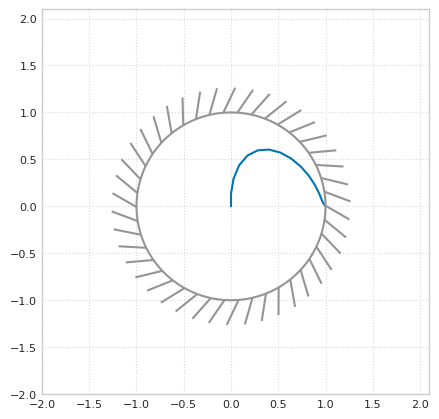

In [11]:
# Apply the STGF controller
n_steps = 20
x0 = np.array([0., 0.])[:, None]
u0 = np.array([0])[:, None]

xu0 = np.zeros((T*n+(T-1)*m, 1))
xu0[0:n, :] = x0
xu0[n*T:n*T+m] = u0
for i in range(T-1):
  xu0[n*T+m*i:n*T+m*(i+1)] = u0  # Potentially useful for using some nominal controller to stabilize the system
  xu0[n*(i+1):n*(i+2)] = xu0[n*i:n*(i+1)] + dt*f(x0.flatten(), u0.flatten())[:, None]

n_iters = 1  # Number of iterations of the safe gradient flow update per step of the dynamical system

start_time = time.time()  # Time how long running the simulation with this control approach takes

xs = np.zeros((n_steps+1, T*n+(T-1)*m, 1))
xs[0] = xu0
for i in range(n_steps):
  xs_new = np.array(xs[i][n*T-n:n*T] + dt*f(xs[i][n*T-n:n*T], xs[i][-m:]))
  x_next = np.vstack([np.roll(xs[i][:T*n], -n), np.roll(xs[i][T*n:], -m)])  # Roll forward one step
  x_next[n*T-n:n*T] = xs_new  # Set next step x from dynamics
  x_next[-m:] = xs[i][-m:]  # Copy last control action to next step
  for j in range(n_iters):
    x_next = solver.step(x_next, eta=dt, args=[x_next[:n, :]], alpha_args=[1.], solver_opts={})

  xs[i+1] = x_next

print("--- %s seconds ---" % (time.time() - start_time))

fig = plt.figure(figsize=(5,5))
plt.plot(xs[:, 0, 0], xs[:, 1, 0]);
y_domain, x_domain = (-2, 2), (-2, 2)
plot_2d_constraints(gx[0, :], Matrix(xt[:2, 1]), y_domain, x_domain);
plt.ylim(-2, 2.1);
plt.xlim(-2, 2.1);

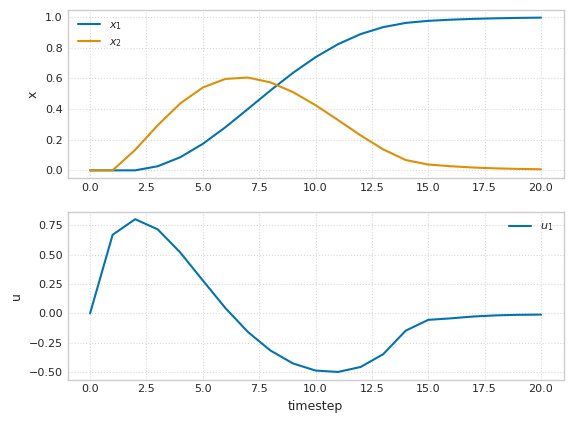

In [12]:
# Plot the states and the inputs over time
plt.subplot(2,1,1)
plt.plot(xs[:, 0, :], label="$x_1$")
plt.plot(xs[:, 1, :], label="$x_2$")
plt.ylabel("x")
plt.legend()
plt.subplot(2,1,2)
plt.plot(xs[:, n*T, :], label="$u_1$");
plt.ylabel("u")
plt.xlabel("timestep")
plt.legend()

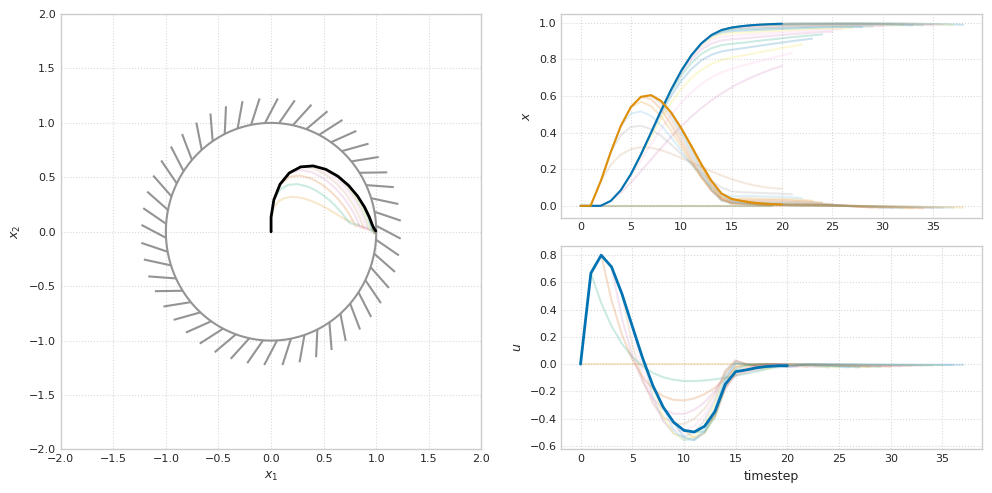

In [13]:
# Define a function to plot the results nicely in one plot
def plot_results(xs, T=T, gx=None, xt=[], y_domain=(-2, 2), x_domain=(-2, 2), plot_traj=True):
  fig = plt.figure(figsize=(15,5))

  axs = []
  axs.append(plt.subplot(1,3,1))
  plt.plot(xs[:, 0, 0], xs[:, 1, 0], color='k', lw=2, zorder=4);
  if gx is not None:
    plot_2d_constraints(gx, Matrix(xt), y_domain, x_domain);

  if plot_traj:
    for i in range(n_steps):
      plt.plot(xs[i, 0:T*n:n, :], xs[i, 1:T*n+1:n, :], marker='', alpha=0.2, zorder=1)

  plt.xlabel("$x_1$")
  plt.ylabel("$x_2$")

  plt.ylim(*y_domain)
  plt.xlim(*x_domain)

  axs.append(plt.subplot(2,3,2))
  plt.plot(xs[:, :n, 0], zorder=4)
  if plot_traj:
    for i in range(n_steps):
      plt.plot(range(i,i+T), xs[i, 0:T*n, :].reshape((T,n)), marker='', alpha=0.2, zorder=1)

  plt.ylabel("$x$")
  axs.append(plt.subplot(2,3,5))
  plt.plot(xs[:, n*T:n*T+m, 0], lw=2, zorder=4);
  if plot_traj:
    for i in range(n_steps):
      plt.plot(range(i,i+T-1), xs[i, T*n:, :].reshape((T-1,m)), marker='', alpha=0.2, zorder=1)
  plt.ylabel("$u$")
  plt.xlabel("timestep")

  plt.tight_layout();
  return axs

plot_results(xs, T=T, gx=gx[0, :], xt=Matrix(xt[:2, 1]));

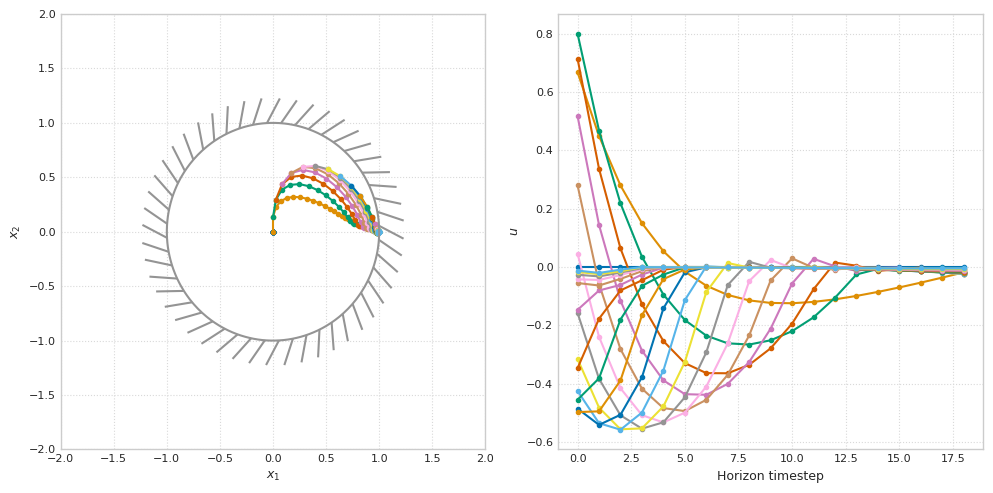

In [14]:
# Plot how is the predicted trajectory evolves
fig = plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
for i in range(n_steps):
  plt.plot(xs[i, 0:T*n:n, :], xs[i, 1:T*n+1:n, :], marker='.')

plot_2d_constraints(gx[0, :], Matrix(xt[:2, 1]), y_domain, x_domain);
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

plt.subplot(1,2,2)
for i in range(n_steps):
  plt.plot(xs[i, T*n:, :], marker='.')
plt.ylabel("$u$")
plt.xlabel("Horizon timestep")

plt.tight_layout()

### Simulate the system

Check that the control inputs found above produce a similar trajectory in a simulation environment

In [15]:
# Define functions for simulation
from scipy.integrate import solve_ivp
def simulate(fx, x0, fu, T, dt=dt):
  xs = np.zeros((T, *x0.shape))
  u0 = fu(0, x0)
  us = np.zeros((T-1, *u0.shape))

  xs[0] = x0
  us[0] = u0
  for i in range(T-1):
    us[i] = fu(i, xs[i])
    ivp_sol = solve_ivp(fx, (i*dt,(i+1)*dt), xs[i].flatten(), args=(us[i].flatten()))
    xs[i+1] = ivp_sol.y[:, -1:]
    # xs[i+1] = xs[i] + dt*fx(i, xs[i].flatten(), us[i].flatten())[:, None]  # Instead using forward euler discretization
  return xs, us

def simfu(t, x):  # Take control input from iterations above
  return xs[t, T*n, :]

def simfx(t, x, u):
  x = x.reshape(-1, 1)  # Add dimension for lambdified function
  u = u.reshape(-1, 1)
  return f(x, u).flatten()  # Flatten for solve_ivp compatibility

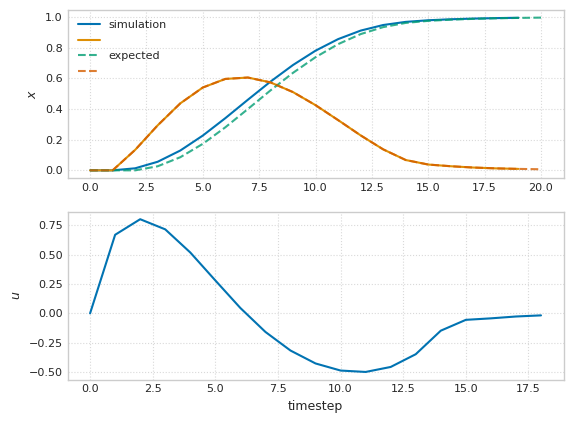

In [16]:
# Simulate and plot the state trajectories comparing those from the simulation and the
xs_sim, us_sim = simulate(simfx, x0, simfu, T=n_steps)
plt.subplot(2,1,1)
plt.plot(xs_sim[:, :2, 0])
plt.plot(xs[:, :2, 0], alpha=0.8, linestyle='--')
plt.ylabel("$x$")
plt.legend(["simulation", "", "expected", ""])
plt.subplot(2,1,2)
plt.plot(us_sim)
plt.ylabel('$u$')
plt.xlabel("timestep");

## Application to a Grid-interfacing Inverter System

### Define the full system dynamics

Start with a model of an inverter connected to an infinite bus through an $LCL$ filter

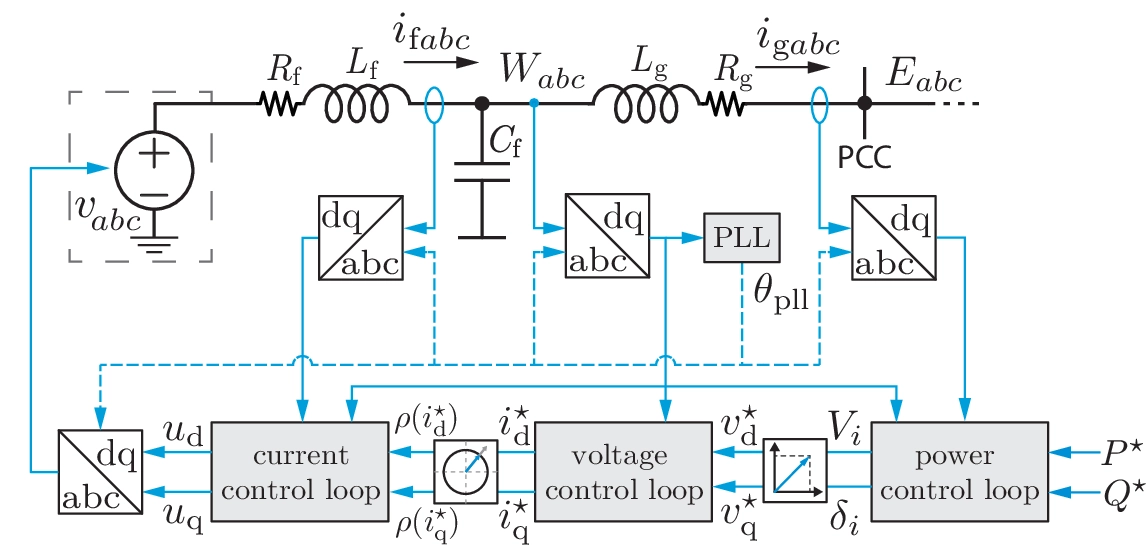

In [17]:
# Create an empty dictionary to store the states and dynamics as they are defined
state_dynamics = {}
algebraic_expressions = {}

n_states = 12 # number of states
n_inputs = 2  # number of inputs
n_outputs = 2  # number of outputs

from sympy.physics.mechanics import init_vprinting
init_vprinting()

def display_alg_eq(lhs_exprs, rhs_exprs, eval=False, alist=True):
  if alist:
    return Eq(Matrix([[lhs] for lhs in lhs_exprs]), Matrix([[rhs] for rhs in rhs_exprs]), evaluate=eval)
  else:
    return Eq(lhs_exprs, rhs_exprs)
def display_diff_eq(states, dynamics, eval=False):
  return Eq(sym.diff(Matrix([[state] for state in states])), Matrix([[dyn] for dyn in dynamics]), evaluate=eval)
def display_aligned_eqs(lhs, rhs):
  # Create the equation
  equation = Eq(lhs, rhs)
  # Convert the equation to LaTeX format
  latex_equation = latex(equation)
  # Display the LaTeX-formatted equation using Math
  return Math(r'\begin{align*}' + latex_equation + r'\end{align*}')

In [18]:
""" DQ reference frame power equations """
vd, vq, id, iq = dynamicsymbols(r"v_\mathrm{d}, v_\mathrm{q}, i_\mathrm{d}, i_\mathrm{q}")
p, q = dynamicsymbols("P, Q")
P = 3/2 * (vd * id + vq * iq)
Q = 3/2 * (vq * id - vd * iq)
display_alg_eq([p, q], [P, Q])

⎡P⎤   ⎡1.5⋅i_\mathrm{d}⋅v_\mathrm{d} + 1.5⋅i_\mathrm{q}⋅v_\mathrm{q}⎤
⎢ ⎥ = ⎢                                                             ⎥
⎣Q⎦   ⎣1.5⋅i_\mathrm{d}⋅v_\mathrm{q} - 1.5⋅i_\mathrm{q}⋅v_\mathrm{d}⎦

In [19]:
""" LCL filter """
# States
i_i_d, i_i_q = dynamicsymbols(r"I_{i\mathrm{d}}, I_{i\mathrm{q}}")  # inverter-side inductor currents
w_d, w_q = dynamicsymbols(r"W_{\mathrm{d}}, W_{\mathrm{q}}")  # capacitor voltages
i_g_d, i_g_q = dynamicsymbols(r"I_{g\mathrm{d}}, I_{g\mathrm{q}}")  # grid-side inductor currents
grid_ref_delta  = dynamicsymbols(r"\delta_g")  # angular difference between the grid voltage angle and the reference angle

# Variables
v_i_d, v_i_q = var(r"V_{i\mathrm{d}}, V_{i\mathrm{q}}")  # inverter output voltage in the dq-reference frame wrt the reference angle theta_ref
e_D, e_Q = var(r"e_\mathrm{D}, e_\mathrm{Q}")  # grid voltages in the grid reference frame
e, omega_e = var(r"E, omega_e")  # grid voltage magnitude and angular frequency
v_nom, omega_nom = var(r"V_\mathrm{nom}, \omega_\mathrm{nom}")
r_i, l_i = var(r"R_i, L_i")  # inverter-side inductor resistance and inductance
r_c, c = var(r"R_c, C")  # capacitor resistance and capacitance
r_g, l_g = var(r"R_g, L_g")  # grid-side inductor resistance and inductance

omega_ref_frame = var(r"\omega_\mathrm{frame}")  # angular frequency of the reference angle, theta_ref

# Collect direct-quadrature components into vectors
v_i_dq = Matrix([[v_i_d], [v_i_q]])
i_i_dq = Matrix([i_i_d, i_i_q])
w_dq = Matrix([[w_d], [w_q]])
i_g_dq = Matrix([i_g_d, i_g_q])
e_DQ = Matrix([[e_D], [e_Q]]).subs({e_D: sqrt(2)*e, e_Q: 0})  # Stiff-grid

# Algebraic equations
Rmat = lambda delta: Matrix([[sym.cos(delta), sym.sin(delta)], [-sym.sin(delta), sym.cos(delta)]]) # Counter-clockwise rotation matrix

E_dq = Rmat(-grid_ref_delta) @ e_DQ  # convert grid voltage to reference theta_ref
E_q = E_dq[1]
E_d = E_dq[0]

# RL Branch dynamics
r, l = var("R, L")
i_d, i_q = dynamicsymbols(r"I_{\mathrm{d}}, I_{\mathrm{q}}")
i_dq = Matrix([[i_d], [i_q]])
v1_d, v1_q = dynamicsymbols(r"V_{1\mathrm{d}}, V_{1\mathrm{q}}")
v2_d, v2_q = dynamicsymbols(r"V_{2\mathrm{d}}, V_{2\mathrm{q}}")
v1_dq, v2_dq = Matrix([[v1_d], [v1_q]]), Matrix([[v2_d], [v2_q]])
A = Matrix([[-r / l, omega_ref_frame ], [-omega_ref_frame , -r / l]])
I_dq_dot = A * i_dq + (v1_dq - v2_dq) / l
I_d_dot = I_dq_dot[0]
I_q_dot = I_dq_dot[1]

### LCL Filter Differential equations ###

# inverter-side inductor dynamics
L_i_subs = {i_d: i_i_d, i_q: i_i_q, r: r_i, l: l_i,
            v1_d: v_i_d, v1_q: v_i_q, v2_d: w_d, v2_q: w_q}
I_i_dot = I_dq_dot.subs(L_i_subs)
I_i_d_dot = I_i_dot[0]
I_i_q_dot = I_i_dot[1]

# grid-side inductor dynamics
L_g_subs = {i_d: i_g_d, i_q: i_g_q, r: r_g, l: l_g,
            v1_d: w_d, v1_q: w_q, v2_d: E_d, v2_q: E_q}
I_g_dot = I_dq_dot.subs(L_g_subs)
I_g_d_dot = I_g_dot[0]
I_g_q_dot = I_g_dot[1]

# capacitor dynamics
A_w = Matrix([[0, omega_ref_frame ], [-omega_ref_frame , 0]])
W_dot = A_w * w_dq + (1 / c) * (i_i_dq - i_g_dq)
W_d_dot = W_dot[0]
W_q_dot = W_dot[1]

### Collect and display the dynamics ###
LCL_Filter_states = [*i_i_dq, *w_dq, *i_g_dq]
LCL_Filter_dynamics = [*I_i_dot, *W_dot, *I_g_dot]
state_dynamics.update(zip(LCL_Filter_states, LCL_Filter_dynamics))
display_diff_eq(LCL_Filter_states, LCL_Filter_dynamics)

                    ⎡                                                 Rᵢ⋅I_{i\ ↪
                    ⎢         \omega_\mathrm{frame}⋅I_{i\mathrm{q}} - ──────── ↪
                    ⎢                                                          ↪
                    ⎢                                                          ↪
                    ⎢                                                  Rᵢ⋅I_{i ↪
                    ⎢         -\omega_\mathrm{frame}⋅I_{i\mathrm{d}} - ─────── ↪
⎡I_{i\maṫhrm{d}}⎤   ⎢                                                          ↪
⎢               ⎥   ⎢                                                          ↪
⎢I_{i\maṫhrm{q}}⎥   ⎢                                                          ↪
⎢               ⎥   ⎢                   \omega_\mathrm{frame}⋅W_{\mathrm{q}} + ↪
⎢W_{\matḣrm{d}} ⎥   ⎢                                                          ↪
⎢               ⎥ = ⎢                                                          ↪
⎢W_{\matḣrm{q}} ⎥   ⎢   

In [20]:
""" Power Controller """

# control inputs
# u = Matrix(dynamicsymbols(','.join(['u_%s' % (i+1) for i in range(n_inputs)])))
v_i = dynamicsymbols(r"V_i")  # inverter voltage magnitude
p_ref, q_ref = symbols(r"P^*, Q^*")
v_ref, omega_ref = symbols(r"V^*, \omega^*")
theta_i, delta_i, omega_i = dynamicsymbols(r"\theta_i, \delta_i, \omega_i")  # inverter voltage angle and angular frequency
inv_ref_delta = delta_i  # angular difference between the inverter voltage angle and the reference angle

v_delta = Matrix([[v_i], [delta_i]])
v_theta = Matrix([[v_i], [theta_i]])

# parameters
k = MatrixSymbol('K', n_inputs, n_outputs)

# linear feedback controller
y = Matrix(dynamicsymbols(','.join(['y_%s' % (i+1) for i in range(n_outputs)])))
f_u_K = k @ y
V_Delta_ref = k @ Matrix([[p - p_ref], [q - q_ref]])

V_i_dq_ref = Rmat(-inv_ref_delta) @ Matrix([[sqrt(2)*v_i], [0]])  # Clockwise rotation since V_i is not reference
V_i_d_ref = V_i_dq_ref[0]
V_i_q_ref = V_i_dq_ref[1]

algebraic_expressions.update(zip(v_delta, V_Delta_ref))

### Display the power controller expression ###
display_alg_eq(v_delta, V_Delta_ref, alist=False)

⎡  Vᵢ   ⎤     ⎡-P__* + P⎤
⎢       ⎥ = K⋅⎢         ⎥
⎣\deltaᵢ⎦     ⎣-Q__* + Q⎦

In [21]:
""" Reference frame """
grid_ref_delta_dot = omega_e - omega_ref_frame
state_dynamics.update({grid_ref_delta: grid_ref_delta_dot})

In [22]:
""" Power expressions """
P_capacitor_grid = P.subs([(vd, w_d), (vq, w_q), (id, i_g_d), (iq, i_g_q)])
Q_capacitor_grid = Q.subs([(vd, w_d), (vq, w_q), (id, i_g_d), (iq, i_g_q)])

P_inv_grid = P.subs([(vd, sqrt(2)*v_i), (vq, 0.0), (id, i_g_d), (iq, i_g_q)])
Q_inv_grid = Q.subs([(vd, sqrt(2)*v_i), (vq, 0.0), (id, i_g_d), (iq, i_g_q)])

algebraic_expressions.update(zip([p, q], [P_capacitor_grid, Q_capacitor_grid]))
display_alg_eq([p, q], [P_capacitor_grid, Q_capacitor_grid])

⎡P⎤   ⎡1.5⋅I_{g\mathrm{d}}⋅W_{\mathrm{d}} + 1.5⋅I_{g\mathrm{q}}⋅W_{\mathrm{q}}⎤
⎢ ⎥ = ⎢                                                                       ⎥
⎣Q⎦   ⎣1.5⋅I_{g\mathrm{d}}⋅W_{\mathrm{q}} - 1.5⋅I_{g\mathrm{q}}⋅W_{\mathrm{d}}⎦

### Define the simplified inverter-grid model

Working with the full model can be challenging due to numerical stability issues with the QP solver. For this project we opt to use a simplified model defined below, and reserve implementing inner control loops with the full-order model for future work.

In [23]:
""" Collect states """
x = Matrix([[i_i_d], [i_i_q], [grid_ref_delta]])
print("n_states", x.shape[0])
Eq(Symbol('x'), x, evaluate=False)

n_states 3


    ⎡I_{i\mathrm{d}}⎤
    ⎢               ⎥
x = ⎢I_{i\mathrm{q}}⎥
    ⎢               ⎥
    ⎣   \delta_g    ⎦

In [24]:
""" Define inputs """
u = Matrix([[v_i], [omega_i]])
u

⎡  Vᵢ   ⎤
⎢       ⎥
⎣\omegaᵢ⎦

In [25]:
""" Collect dynamics """
ref_frame_subs = [(inv_ref_delta, delta_i),  # inverter angle reference frame
                  (omega_ref_frame, omega_i),  # inverter angular frequency expression
                  (v_i_d, sqrt(2)*v_i),  # v_i_dq becomes (sqrt(2) v_i, 0) with this choice of reference
                  (v_i_q, 0),
                  (w_d, E_d),  # ignore capacitor dynamics
                  (w_q, E_q)
                  ]

x_dot_diff_eqs = Matrix([[state_dynamics[state]] for state in x])

display_diff_eq(x, x_dot_diff_eqs)

                    ⎡                                        Rᵢ⋅I_{i\mathrm{d} ↪
                    ⎢\omega_\mathrm{frame}⋅I_{i\mathrm{q}} - ───────────────── ↪
⎡I_{i\maṫhrm{d}}⎤   ⎢                                                Lᵢ        ↪
⎢               ⎥   ⎢                                                          ↪
⎢I_{i\maṫhrm{q}}⎥ = ⎢                                         Rᵢ⋅I_{i\mathrm{q ↪
⎢               ⎥   ⎢-\omega_\mathrm{frame}⋅I_{i\mathrm{d}} - ──────────────── ↪
⎣   \delṫa_g    ⎦   ⎢                                                 Lᵢ       ↪
                    ⎢                                                          ↪
                    ⎣                                 -\omega_\mathrm{frame} + ↪

↪ }   V_{i\mathrm{d}} - W_{\mathrm{d}} ⎤
↪ ─ + ──────────────────────────────── ⎥
↪                    Lᵢ                ⎥
↪                                      ⎥
↪ }}   V_{i\mathrm{q}} - W_{\mathrm{q}}⎥
↪ ── + ────────────────────────────────⎥
↪                    

In [26]:
# Seperate out algebraic expressions into lists for display
P_grid = P.subs([(vd, E_d), (vq, E_q), (id, i_i_d), (iq, i_i_q)])
Q_grid = Q.subs([(vd, E_d), (vq, E_q), (id, i_i_d), (iq, i_i_q)])

algebraic_expressions = {p: P_grid, q: Q_grid}

key_value_pairs = list(algebraic_expressions.items())
x_dot_alg_eqs_LHS = [pair[0] for pair in key_value_pairs]
x_dot_alg_eqs_RHS = [pair[1] for pair in key_value_pairs]
display_alg_eq(x_dot_alg_eqs_LHS, x_dot_alg_eqs_RHS)

⎡P⎤   ⎡2.12132034355964⋅E⋅I_{i\mathrm{d}}⋅cos(\delta_g) + 2.12132034355964⋅E⋅I ↪
⎢ ⎥ = ⎢                                                                        ↪
⎣Q⎦   ⎣2.12132034355964⋅E⋅I_{i\mathrm{d}}⋅sin(\delta_g) - 2.12132034355964⋅E⋅I ↪

↪ _{i\mathrm{q}}⋅sin(\delta_g)⎤
↪                             ⎥
↪ _{i\mathrm{q}}⋅cos(\delta_g)⎦

In [27]:
# Display full dynamics with algebraic expressions substituted in
x_dot = Matrix([[state_dynamics[state]] for state in x]).subs(algebraic_expressions).subs(ref_frame_subs)
display_diff_eq(x, x_dot)

                    ⎡                          Rᵢ⋅I_{i\mathrm{d}}   -1.4142135 ↪
                    ⎢I_{i\mathrm{q}}⋅\omegaᵢ - ────────────────── + ────────── ↪
⎡I_{i\maṫhrm{d}}⎤   ⎢                                  Lᵢ                      ↪
⎢               ⎥   ⎢                                                          ↪
⎢I_{i\maṫhrm{q}}⎥ = ⎢            1.4142135623731⋅E⋅sin(\delta_g)               ↪
⎢               ⎥   ⎢          - ─────────────────────────────── - I_{i\mathrm ↪
⎣   \delṫa_g    ⎦   ⎢                          Lᵢ                              ↪
                    ⎢                                                          ↪
                    ⎣                                            ωₑ - \omegaᵢ  ↪

↪ 623731⋅E⋅cos(\delta_g) + 1.4142135623731⋅Vᵢ⎤
↪ ───────────────────────────────────────────⎥
↪                Lᵢ                          ⎥
↪                                            ⎥
↪                Rᵢ⋅I_{i\mathrm{q}}          ⎥
↪ {d}}⋅\omegaᵢ - ───────────────

In [28]:
# Discretization parameters
delta_t = 1e-3
dt, t = symbols(r'{\Delta}t, t')

In [29]:
# Numeric parameters for the inverter system
s_base = 1500.  # W
v_base = 120.  # Vrms LN
i_base = s_base / (3 * v_base)
z_base = v_base / i_base

f_nom = 60.  # Hz
omega_base = f_nom * 2*np.pi  # rad/s

v_nom_val = v_base
s_rated = s_base

i_max = i_base #* 1.2  # A

e_val = v_nom_val
omega_e_val = f_nom * 2*np.pi

# LCL filter parameters
r_i_val = 0.2
l_i_val = 1.5e-3

# Control parameters
pref0 = 0.5 * s_rated
qref0 = 0.5 * s_rated

mp = symbols("m_p")
mq = symbols("m_q")
tv = symbols(r"\tau_v")
mv = symbols("m_v")
mw = symbols(r"m_\omega")


delta_omega = 1.0 * 2 * np.pi
delta_v = 0.05 * v_nom_val / v_base
# active power droop coefficient
mp_val = delta_omega / (s_rated / s_base)  # omega ~ mp * (P - P^*)
# reactive power droop coefficient
mq_val = delta_v / (s_rated / s_base) # v ~ mq * (Q - Q^*)

mv_val = 1     # voltage scale
mw_val = 1     # frequency scale
tv_val = 0.001 # voltage control time constant

dt_val = delta_t  # assigned at the start of the discretize section

In [30]:
# Dictionaries of per-unit numerical parameters

symbolic_subs = {omega_e: omega_e}

lcl_param_subs = {r_i: r_i_val / z_base, l_i: l_i_val / (z_base)}
nominal_subs = {v_nom: v_nom_val / v_base, e: e_val / v_base, e_Q: 0, omega_e: omega_e_val, omega_nom: 2*np.pi*f_nom}
numeric_subs = {**lcl_param_subs, **nominal_subs, mp: mp_val, mq: mq_val, tv: tv_val, mv: mv_val, mw: mw_val, p_ref: pref0, q_ref: qref0, v_ref: 1.0, omega_ref:omega_e_val}  # Combine numerical substitutions into one dictionary

# pack all subs into one
sim_subs = {**symbolic_subs, **numeric_subs, **nominal_subs, dt: dt_val}

In [31]:
# Determine which parameters we want to be able to modify during the simulation
param_args = [p_ref, q_ref, v_ref, omega_ref, e, omega_e, mp, mq, mv, mw]
for param in param_args:
  if param in sim_subs:
    sim_subs.pop(param)
param_vals = [0, 0, 1., 2*np.pi*60, 1., 2*np.pi*60]

In [32]:
# Define the dynamics
fx = x_dot.subs(sim_subs)
f = lambdify((x,u, param_args), fx)
fx

⎡-27152.9003975634⋅E⋅cos(\delta_g) - 133.333333333333⋅I_{i\mathrm{d}} + I_{i\m ↪
⎢                                                                              ↪
⎢           -27152.9003975634⋅E⋅sin(\delta_g) - I_{i\mathrm{d}}⋅\omegaᵢ - 133. ↪
⎢                                                                              ↪
⎣                                                    ωₑ - \omegaᵢ              ↪

↪ athrm{q}}⋅\omegaᵢ + 27152.9003975634⋅Vᵢ⎤
↪                                        ⎥
↪ 333333333333⋅I_{i\mathrm{q}}           ⎥
↪                                        ⎥
↪                                        ⎦

In [33]:
# Define the objective
Jx = mp/2*(P_grid - p_ref)**2 + (mq/tv)/2*(Q_grid - q_ref)**2 + (mv/tv)/2*(v_i - v_ref)**2 + mw/2*(omega_i - omega_ref)**2
Jx_final = mp/2*(P_grid - p_ref)**2 + (mq/tv)/2*(Q_grid - q_ref)**2  # No inputs in final step
Jx

                               2                                               ↪
m_\omega⋅(-\omega__* + \omegaᵢ)    mₚ⋅(2.12132034355964⋅E⋅I_{i\mathrm{d}}⋅cos( ↪
──────────────────────────────── + ─────────────────────────────────────────── ↪
               2                                                               ↪

↪                                                                     2        ↪
↪ \delta_g) + 2.12132034355964⋅E⋅I_{i\mathrm{q}}⋅sin(\delta_g) - P__*)    m_q⋅ ↪
↪ ───────────────────────────────────────────────────────────────────── + ──── ↪
↪             2                                                                ↪

↪                                                                              ↪
↪ (2.12132034355964⋅E⋅I_{i\mathrm{d}}⋅sin(\delta_g) - 2.12132034355964⋅E⋅I_{i\ ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                  2⋅\tauᵥ                     ↪

↪                        

In [34]:
# Define the constraints
ilim = i_max / i_base
ilim_constr = i_i_d**2 + i_i_q**2 - ilim**2 # <= 0
ilim_constr

               2                  2      
I_{i\mathrm{d}}  + I_{i\mathrm{q}}  - 1.0

In [35]:
# Try to directly solve for the optimal value of the NLP
param_ref_vals = [2.0, -0.5, 1.0 * v_nom_val / v_base, 1.05*omega_base, 1.05*v_nom_val / v_base, 0.95*omega_base, mp_val, mq_val, mv_val, mw_val]

n = x.shape[0]
m = u.shape[0]

def solve_opt(param_vals):

  opti = Opti();

  x_ = opti.variable(n,1);  # Id, Iq, delta
  u_ = opti.variable(m,1);  # V, omega
  r_ = opti.parameter(len(param_args),1);  # P*, Q*, E, omega_e

  e_d_ = sqrt(2)* r_[4]*cos(x_[2])
  e_q_ = sqrt(2)* r_[4]*sin(x_[2])
  P_ = 3/2*(e_d_ * x_[0] + e_q_ * x_[1])
  Q_ = 3/2*(e_q_ * x_[0] - e_d_ * x_[1])

  obj = mp_val/2*(P_ - r_[0])**2 + (mq_val/tv_val)/2*(Q_ - r_[1])**2 + (mv_val/tv_val)/2*(u_[0] - r_[2])**2 + mw_val/2*(u_[-1] - r_[3])**2
  opti.minimize(obj);
  con = x_[0]**2+x_[1]**2 <= 1;
  opti.subject_to(con);
  x1dot = -sim_subs[r_i]/sim_subs[l_i] * x_[0] + u_[-1] * x_[1] + 1/sim_subs[l_i] * (sqrt(2)*u_[0] - e_d_) == 0
  x2dot = -sim_subs[r_i]/sim_subs[l_i] * x_[1] - u_[-1] * x_[0] + 1/sim_subs[l_i] * (0     - e_q_) == 0
  x3dot = r_[5] - u_[-1] == 0
  opti.subject_to(x1dot);
  opti.subject_to(x2dot);
  opti.subject_to(x3dot);

  p_opts = dict(print_time=False, verbose=False)
  s_opts = dict(print_level=0)
  opti.solver('ipopt', p_opts, s_opts);

  r_value = np.array([*param_vals])
  y_ref = r_value
  opti.set_value(r_,r_value)
  sol = opti.solve();

  # Print solution
  x_opt = sol.value(x_)
  u_opt = sol.value(u_)

  return x_opt, u_opt

x_opt, u_opt = solve_opt(param_ref_vals)
print("-----")
print("x = ", x_opt)
print("u = ", u_opt)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

-----
x =  [ 0.89225322  0.21631429 -0.01222016]
u =  [  1.05144983 358.14156251]


In [36]:
# Check if states are at the current limit
np.linalg.norm(x_opt)

np.float64(0.9181813653619962)

In [37]:
# Display the optimal output values for the given constraints and paramters
p_opt = P_grid.subs(sim_subs).subs(zip(x, x_opt)).subs(zip(param_args, param_vals))
q_opt = Q_grid.subs(sim_subs).subs(zip(x, x_opt)).subs(zip(param_args, param_vals))
v_opt = u_opt[0]
omega_opt = u_opt[1]
p_opt, q_opt, v_opt, omega_opt

(1.8870062415246, -0.481966842483084, 1.0514498344671364, 358.1415625092364)

### Define the trajectory optimization problem

In [38]:
# Define the discretized dynamics used in the optimization problem

delta = symbols(r'\Delta')
# Forward Euler discretization
fxt_euler = x + delta*fx
fxt = fxt_euler

# Trapezoidal (RK2) discretization
# xt_hat = x + delta*fx
# fxt_trapezoidal = sym.simplify(x + delta*1/2*(fx.subs(zip(x, xt_hat)) + fx))
#fxt = fxt_trapezoidal

In [39]:
# Define the trajectory optimization problem constraints
n = x.shape[0]
m = u.shape[0]

fxt_ = lambdify((delta, x, u, param_args), fxt, 'numpy')

t_horizon = 10   # Trajectory optimization horizon
step_time = 50  # Power reference step time

T = t_horizon  # > r = 2
xt = MatrixSymbol('x', n, T)
ut = MatrixSymbol('u', m, T-1)

Jx_param = Jx.subs(sim_subs)
Jx_final_param = Jx_final.subs(sim_subs)

Jx_T = 0
for i in range(T-1):
  Jx_T += Jx_param.subs(zip(Matrix(x), Matrix(xt[:, i]))).subs(zip(Matrix(u), Matrix(ut[:, i])))
Jx_T += Jx_final_param.subs(zip(Matrix(x), Matrix(xt[:, T-1])))

x0_param = MatrixSymbol('x_0', n, 1)
xt_constr = [Matrix(xt[:, 0]) - Matrix(x0_param)]  # Fixes x0 value in each iteration
for i in range(T-1):
  xt_constr.append(Matrix(xt[:, i+1]) - Matrix(fxt).subs(zip(Matrix(x), Matrix(xt[:, i]))).subs(zip(Matrix(u), Matrix(ut[:, i]))))

Xt = Matrix(np.array(xt).T.flatten())
Ut = Matrix(np.array(ut).T.flatten())
XUt = Matrix([[Xt], [Ut]])

In [40]:
# inequality constraints, g(x) <= 0
#gx = Matrix([[0]])  # Test with no constraints
gx = Matrix([[ilim_constr.subs(zip(x, Matrix(xt[:, i])))] for i in range(1,T)])  # Initial point x(0) is fixed
l = gx.shape[0]
if XUt.shape[0] < 50:
  dgx = gx.jacobian(XUt)
dgx if XUt.shape[0] < 50 else None

⎡0  0  0  2⋅x₀₁  2⋅x₁₁  0    0      0    0    0      0    0    0      0    0   ↪
⎢                                                                              ↪
⎢0  0  0    0      0    0  2⋅x₀₂  2⋅x₁₂  0    0      0    0    0      0    0   ↪
⎢                                                                              ↪
⎢0  0  0    0      0    0    0      0    0  2⋅x₀₃  2⋅x₁₃  0    0      0    0   ↪
⎢                                                                              ↪
⎢0  0  0    0      0    0    0      0    0    0      0    0  2⋅x₀₄  2⋅x₁₄  0   ↪
⎢                                                                              ↪
⎢0  0  0    0      0    0    0      0    0    0      0    0    0      0    0   ↪
⎢                                                                              ↪
⎢0  0  0    0      0    0    0      0    0    0      0    0    0      0    0   ↪
⎢                                                                              ↪
⎢0  0  0    0      0    0   

In [41]:
# Equality constraints
hx = Matrix(xt_constr)
k = hx.shape[0]
if XUt.shape[0] < 50:
  dhx = hx.jacobian(XUt)
dhx if XUt.shape[0] < 50 else None

⎡             1                            0                                0  ↪
⎢                                                                              ↪
⎢             0                            1                                0  ↪
⎢                                                                              ↪
⎢             0                            0                                1  ↪
⎢                                                                              ↪
⎢133.333333333333⋅\Delta - 1          -\Delta⋅u₁₀          -27152.9003975634⋅E ↪
⎢                                                                              ↪
⎢        \Delta⋅u₁₀           133.333333333333⋅\Delta - 1  27152.9003975634⋅E⋅ ↪
⎢                                                                              ↪
⎢             0                            0                               -1  ↪
⎢                                                                              ↪
⎢             0             

In [42]:
# Intantiate the safe gradient flow solver object
dt = delta_t  # Simulation/dynamics timestep

# Define a class-K function for CBF approach
a = sym.Wild('a')
beta1, beta2 = sym.symbols(r"\beta_1, \beta_2")
alpha = beta1 * (sym.exp(beta2 * a) - 1)  # Aggresive alpha function required to maintain current limit when new step exceeds limit, but cannot be too aggresive or the problem may become infeasible..

# a = sym.Wild('a')
# beta1, beta2, beta3 = sym.symbols(r"\beta_1, \beta_2, \beta_3")
# alpha = beta1 * (1 / (1 + sym.exp(-(beta2 *a - beta3))) - 1 / (1 + sym.exp(-(beta2 * 0 - beta3))))  # Sigmoid-like curve to prevent function value from going to infinity

solver = sgf_solver(XUt, Jx_T.subs(delta, dt), gx.subs(delta, dt), hx.subs(delta, dt), alpha, a,
                    args=[x0_param, *param_args], alpha_args=[beta1, beta2],
                    verbose=True, solver=cp.OSQP) #solver=cp.CLARABEL)

Defining optimization problem...
Differentiating f(x)...
Differentiating g(x)...
Differentiating h(x)...
Generating parameter functions...
Solver initialized!


(-19.865241060018292, 2948.263182051532, -19.865241060018292, 2948.263182051532)

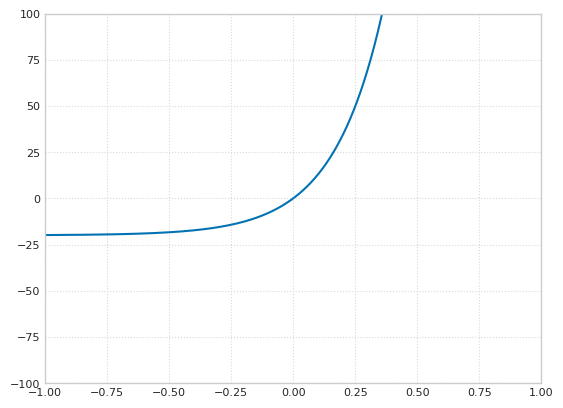

In [43]:
# Plot the alpha function
z = Symbol('z')
alphaf = lambdify(z, alpha.subs(zip([beta1, beta2], [20, 5])).subs(a, z))
test_a = np.linspace(-1,1, 1000)
alpha_vals = alphaf(test_a)
plt.plot(test_a, alphaf(test_a))
plt.ylim(-100, 100)
plt.xlim(-1, 1)
np.min(alphaf(test_a)), np.max(alphaf(test_a)), alphaf(-1), alphaf(1)

In [44]:
# Check if the problem is DCP and DPP
solver.prob.is_dcp(), solver.prob.is_dcp(dpp=True)

(True, False)

In [45]:
# Test the solver was initialized properly
"""
Note that this initial step must be done with nonzero values due to some odd behavior with the OSQP solver.
The following error is thrown if this step is not taken:
"ERROR in osqp_update_data_mat: new number of elements (409) out of bounds for P (293 max)"
"""
p_ref_val, q_ref_val = 0, 0
e_val = 1.
omega_nom_val = 2*np.pi*60
param_val0 = [p_ref_val, q_ref_val, e_val, omega_nom_val, e_val, omega_nom_val, mp_val, mq_val, mv_val, mw_val]

u0 = np.array([v_nom_val / v_base, omega_e_val])[:, None]
sol = sym.solve(fx.subs(zip(u, u0.flatten())).subs(zip(param_args, param_val0)), x)
x_eq = Matrix(sol[0]).subs(x[-1], 0.0001) # Start with a small offset from zero, due to odd behavior with OSQP solver
x0 = np.array(x_eq).astype(float)
x0

param_vals = param_val0

xu0 = np.zeros((T*n+(T-1)*m, 1))
xu0[0:n, :] = x0
xu0[n*T:n*T+m] = u0
for t in range(T-1):
  xu0[n*T+m*t:n*T+m*(t+1)] = u0
  xu0[n*(t+1):n*(t+2)] = xu0[n*t:n*(t+1)] + dt*f(xu0[n*t:n*(t+1)].flatten(), u0.flatten(), param_vals)

x_test = solver.step(xu0, eta=dt, args=[xu0[:n, :], *param_vals], alpha_args=[20., 2.], solver_opts={'warm_start': False,'max_iter': 10000}).T;
#x_test = solver.step(xu0, eta=dt, args=[xu0[:n, :], *param_vals], alpha_args=[1000, 20, 4], solver_opts={'warm_start': False,'max_iter': 10000}).T;

(CVXPY) Jan 14 09:48:35 PM: Your problem has 39 variables, 39 constraints, and 1290 parameters.
(CVXPY) Jan 14 09:48:35 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jan 14 09:48:35 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jan 14 09:48:35 PM: Your problem is compiled with the CPP canonicalization backend.
/usr/local/lib/python3.12/dist-packages/cvxpy/reductions/solvers/solving_chain.py:241: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  warnings.warn(DPP_ERROR_MSG)
(CVXPY) Jan 14 09:48:35 PM: Compiling problem (target solver=OSQP).
(CVXPY) Jan 14 09:48:35 PM: Reduction chain: EvalParams -> CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> OSQP
(C

                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 39, constraints m = 39
          nnz(P) + nnz(A) = 416
settings: algebra = Built-in,
          OSQPInt = 4

## Implement & Test Controllers

In [46]:
# Test parameter reference values
                               # P*,  Q*,  V_i*,               omega_i*,     E_grid,         omega_grid
test_param_ref_vals = np.array([[2.5, -0.5, v_nom_val / v_base, omega_base, v_nom_val / v_base, omega_base],            # Test 0
                                [2.5, 0.5, v_nom_val / v_base, omega_base, v_nom_val / v_base, omega_base],             # Test 1
                                [0.5, 2.5, v_nom_val / v_base, omega_base, v_nom_val / v_base, omega_base] ,            # Test 2
                                [-0.5, -2.5, v_nom_val / v_base, omega_base, v_nom_val / v_base, omega_base] ,          # Test 3
                                [1.0, 1.0, v_nom_val / v_base, omega_base, v_nom_val / v_base, omega_base] ,            # Test 4
                                [1.0, -1.0, v_nom_val / v_base, omega_base, v_nom_val / v_base, omega_base] ,           # Test 5
                                [-1.0, 1.0, v_nom_val / v_base, omega_base, v_nom_val / v_base, omega_base] ,           # Test 6
                                [1.0, -1.0, v_nom_val / v_base, omega_base, v_nom_val / v_base, omega_base],            # Test 7
                              ])

In [47]:
# Pick test param values to use
test = 0
param_ref_vals = np.array([*test_param_ref_vals[test, :], mp_val, mq_val, mv_val, mw_val])
param_ref_vals

array([ 2.50000000e+00, -5.00000000e-01,  1.00000000e+00,  3.76991118e+02,
        1.00000000e+00,  3.76991118e+02,  6.28318531e+00,  5.00000000e-02,
        1.00000000e+00,  1.00000000e+00])

In [48]:
# Find the optimal equilibrium values
x_opt, u_opt = solve_opt(param_ref_vals)

p_opt = P_grid.subs(sim_subs).subs(zip(x, x_opt)).subs(zip(param_args, param_vals))
q_opt = Q_grid.subs(sim_subs).subs(zip(x, x_opt)).subs(zip(param_args, param_vals))
v_opt = u_opt[0]
omega_opt = u_opt[1]

*x_opt, p_opt, q_opt, v_opt, omega_opt

(0.9765087693342903, 0.21547766642864438, -0.014616472432586937, 2.06458573423 ↪

↪ 41, -0.487325098799969, 1.0016965982908406, 376.99111843077515)

### STGF controller

In [49]:
# Determine feasible initial conditions
p_ref_val, q_ref_val = 0*s_base/s_base, 0*s_base/s_base  # Initialize at zero power
e_val = 1.
omega_nom_val = 2*np.pi*60
param_val0 = [p_ref_val, q_ref_val, e_val, omega_nom_val, e_val, omega_nom_val, mp_val, mq_val, mv_val, mw_val]
u0 = np.array([v_nom_val / v_base, omega_e_val])[:, None]
sol = sym.solve(fx.subs(zip(u, u0.flatten())).subs(zip(param_args, param_val0)), x)
x_eq = Matrix(sol[0]).subs(x[2], 0.0 )
x0 = np.array(x_eq).astype(float)
x0

array([[0.],
       [0.],
       [0.]])

Iter: 0 --- 0.0025513172149658203 seconds ---
ERROR in osqp_update_data_mat: index vector is required for partial updates of P
Iter: 30 --- 0.7634446620941162 seconds ---
Iter: 60 --- 1.7749671936035156 seconds ---
Iter: 90 --- 2.8564281463623047 seconds ---

Stepping Parameter Values
Iter: 120 --- 3.9326183795928955 seconds ---
Iter: 150 --- 4.706788539886475 seconds ---
Iter: 180 --- 5.508259057998657 seconds ---
Iter: 210 --- 6.308202028274536 seconds ---
Iter: 240 --- 7.100729942321777 seconds ---
Iter: 270 --- 7.897264003753662 seconds ---


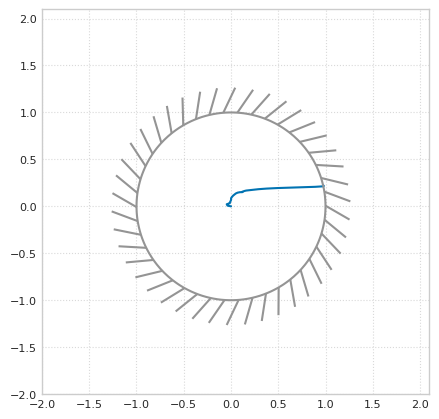

In [50]:
from scipy.integrate import solve_ivp

def simfx(t, x, u, param):
  return f(x, u, param).flatten()

solver.verbose=False

T_sim = 300
T = t_horizon  # Trajectory optimization horizon
n_steps = T_sim # Number of simulation timesteps
n_iters = 2 # Number of iterations of the STGF algorithm each time step
step_time = 100 #100  # Power reference step time

param_vals = list(param_val0)

param_sim_vals = list(param_vals)
param_t_val_record = []

# Initialize simulation values
xs_sim = np.zeros((n_steps+1, *x0.shape))
us_sim = np.zeros((n_steps, *u0.shape))

xu0 = np.zeros((T*n+(T-1)*m, 1))
xu0[0:n, :] = x0
xu0[n*T:n*T+m] = u0
for t in range(T-1):
  xu0[n*T+m*t:n*T+m*(t+1)] = u0  # Useful for using some nominal controller to stabalize the system?
  xu0[n*(t+1):n*(t+2)] = xu0[n*t:n*(t+1)] + dt*f(xu0[n*t:n*(t+1)].flatten(), u0.flatten(), param_vals)

start_time = time.time()
stgf_solve_times = []

xs = np.zeros((n_steps+1, T*n+(T-1)*m, 1))
xs[0] = xu0

xus_preopt = np.zeros((n_steps+1, T*n+(T-1)*m, n_iters+1))  # Save trajectories for each optimizing step
xus_preopt[0, :, :] = xu0

mu_vals = []

xs_sim[0] = np.array(x0)
us_sim[0] = np.array(u0)
for i in range(n_steps):
  if i % (n_steps // 10) == 0:
    print("Iter: %s --- %s seconds ---" % (i, time.time() - start_time))
  #solve_time = time.time()
  step_solve_time = 0

  # Roll forward the trajectory
  last_step_us = np.array(xs[i][-m:])
  new_step_xs = np.array(xs[i][n*T-n:n*T] + dt*f(xs[i][n*T-n:n*T].flatten(), last_step_us.flatten(), param_vals))
  x_next = np.vstack([np.roll(xs[i][:T*n], -n), np.roll(xs[i][T*n:], -m)])  # Roll trajectory forward one step
  x_next[n*T-n:n*T] = new_step_xs  # Set next step x from dynamics
  x_next[-m:] = last_step_us # Copy last control action to new step
  # x_next[-m:] = np.array(u0)  # Copy nominal control action to next step
  # x_next[-m:] = 0.2*param_ref_vals[4:6, None] + 0.8*last_step_us # Weight between nominal action and last step

  # Step parameters (known disturbances)
  if i == step_time:
    print("")
    print("Stepping Parameter Values")
    param_vals = [*param_ref_vals]
    param_sim_vals = [*param_ref_vals]  # Also updated the simulation values to align

  param_t_val_record.append(list(param_vals))  # Save param vals in each time step

  # Update x0 to align with the simulation from measured current state
  x_next[0:n] = xs_sim[i]
  for t in range(T-1):  # update state predictions in case a disturbance has occured
    x_next[n*(t+1):n*(t+2)] = x_next[n*t:n*(t+1)] + dt*f(x_next[n*t:n*(t+1)].flatten(), x_next[n*T+m*t:n*T+m*(t+1)].flatten(), param_vals)

  xus_preopt[i, :, 0:1] = x_next

  for j in range(n_iters):
    try:# 1e0, 1e-1  # 20, 6
      x_next = solver.step(x_next, eta=dt, args=[x_next[:n, :], *param_vals], alpha_args=[17., 6.], solver_opts={'warm_start': True,'max_iter': 10000, 'eps_abs':1e0, 'eps_rel':1e-1})  # We can use large tolerance for this problem and still get steps that minimally differ from gradient descent
    except cp.error.SolverError:
      print("Solver failed to converge within the iteration limit. Lowering alpha...")
      x_next = solver.step(x_next, eta=dt, args=[x_next[:n, :], *param_vals], alpha_args=[5., 1.], solver_opts={'warm_start': True, 'max_iter': 10000})
    except ValueError():
      print("Solver failed to find a feasible point. Lowering alpha and solver tolerances...")
      x_next = solver.step(x_next, eta=dt, args=[x_next[:n, :], *param_vals], alpha_args=[20, 5.], solver_opts={'warm_start': True, 'max_iter': 10000, 'eps_abs': 1e-1, 'eps_rel': 1e-1, 'eps_prim_inf': 1e-4, 'eps_dual_inf': 1e-4})
    step_solve_time += solver.prob.solver_stats.solve_time
    xus_preopt[i, :, j+1:] = x_next
  xs[i+1] = x_next

  u_ctrl = np.array(x_next[n*T:n*T+m])

  #stgf_solve_times.append(time.time() - solve_time)
  stgf_solve_times.append(step_solve_time)

  mu_vals.append(np.array(solver.vars[0].value))

  # Apply control action to the simulated system
  us_sim[i] = u_ctrl
  #xs_sim[i+1] = xs_sim[i] + dt*simfx(i, xs_sim[i].flatten(), us_sim[i].flatten(), param_sim_vals)
  ivp_sol = solve_ivp(simfx, (i*dt,(i+1)*dt), xs_sim[i].flatten(), args=(us_sim[i].flatten(), param_sim_vals))
  xs_sim[i+1] = ivp_sol.y[:, -1:]

xus_stgf = np.array(xs) # Copy stgf data for later plotting

fig = plt.figure(figsize=(5,5))
plt.plot(xs[:, 0, 0], xs[:, 1, 0]);
y_domain, x_domain = (-2, 2), (-2, 2)
plot_2d_constraints(gx[0, :], Matrix(xt[:2, 1]), y_domain, x_domain);

plt.ylim(-2, 2.1);
plt.xlim(-2, 2.1);

average solve time:  0.5311549200000001  ms
solve time variance:  3.4830363517753595e-05  ms
max solve time:  2.4420509999999997  ms
min solve time:  0.43777699999999997  ms


Text(0, 0.5, 'solve time (ms)')

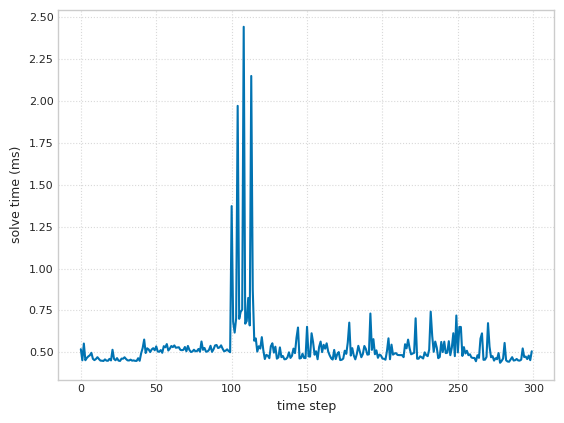

In [51]:
# Check the average solve time
print("average solve time: ", np.mean(np.array(stgf_solve_times))*1000, ' ms')
print("solve time variance: ", np.var(np.array(stgf_solve_times))*1000, ' ms')
print("max solve time: ", np.max(np.array(stgf_solve_times))*1000, ' ms')
print("min solve time: ", np.min(np.array(stgf_solve_times))*1000, ' ms')
plt.plot(np.array(stgf_solve_times)*1000)
plt.xlabel("time step")
plt.ylabel("solve time (ms)")

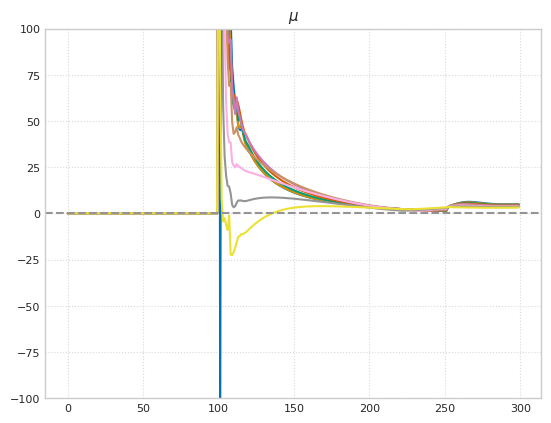

In [52]:
# Check optimization problem mu values
plt.plot(np.array(mu_vals)[:, :, 0]);
plt.ylim(-100, 100);
#plt.xlim(-1, 50);
plt.axhline(0, linestyle='--', color='C7');
plt.title(r"$\mu$");

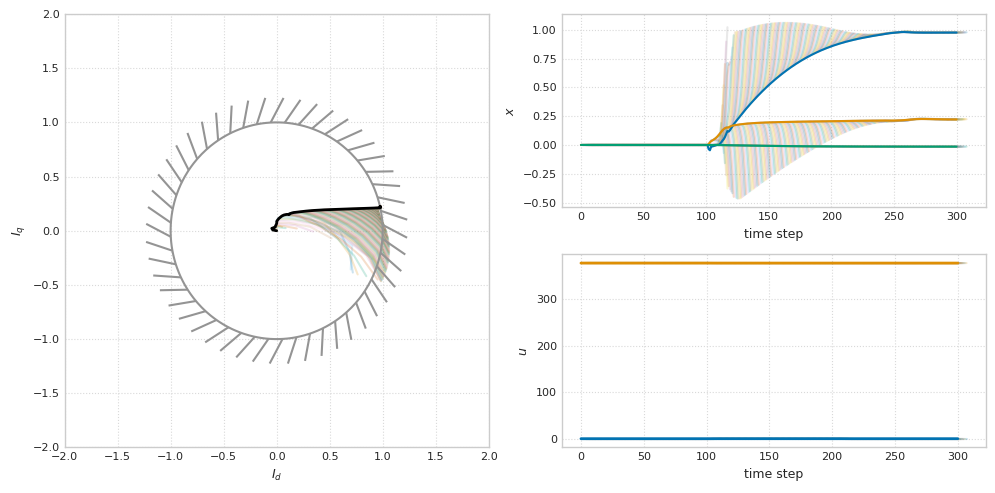

In [53]:
# Plot the predicted trajectories and the current constraints
ax = plot_results(xs, t_horizon, gx[0, :], Matrix(xt[:2, 1])) # If constraints are on <= 2 states, visualize them

ax[0].set_xlabel("$I_d$")
ax[0].set_ylabel("$I_q$")
ax[1].set_ylabel("$x$")
ax[1].set_xlabel("time step")
ax[2].set_ylabel("$u$")
ax[2].set_xlabel("time step")
plt.tight_layout()

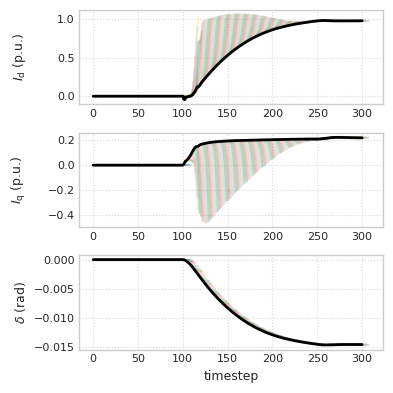

In [54]:
# Plot the states over time
fig = plt.figure(figsize=(4,4))
y_labels = [r"$I_\mathrm{d}$ (p.u.)", r"$I_\mathrm{q}$ (p.u.)", r"$\delta$ (rad)"]

for i_state in range(n):
  plt.subplot(n,1,i_state+1)
  plt.plot(xs_sim[:, i_state, 0], lw=2, color='k');

  for i in range(n_steps):
    plt.plot(range(i,i+T), xus_stgf [i, i_state:T*n:n, :].reshape((T,1)), marker='', alpha=0.2, zorder=1)
  plt.ylabel(y_labels[i_state])
plt.xlabel("timestep")
fig.align_ylabels()
plt.tight_layout();

fname="states.pdf"
plt.savefig(fname, dpi=300, format=None, metadata=None,
        bbox_inches=None, pad_inches=0.0,
        facecolor='auto', edgecolor='auto',
        backend=None
       )

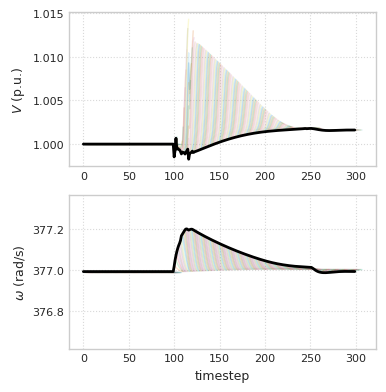

In [55]:
# Plot the inputs over time
fig = plt.figure(figsize=(4,4))
y_labels = ["$V$ (p.u.)", r"$\omega$ (rad/s)"]

axs = []
for i_input in range(m):
  ax = plt.subplot(m,1,i_input+1)
  plt.plot(us_sim[:, i_input, 0], lw=2, color='k');

  axs.append(ax)

  plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab10.colors)

  for i in range(n_steps):
    plt.plot(range(i,i+T-1), xus_stgf [i, T*n+i_input::m, :].reshape((T-1,1)),
             marker='', alpha=0.2, zorder=1, lw=1)
  plt.ylabel(y_labels[i_input])
plt.xlabel("timestep")
fig.align_ylabels()
plt.tight_layout();

axs[1].set_ylim(omega_base*0.999, omega_base*1.001)

fname="inputs.pdf"
plt.savefig(fname, dpi=300, format=None, metadata=None,
        bbox_inches=None, pad_inches=0.0,
        facecolor='auto', edgecolor='auto',
        backend=None
       )

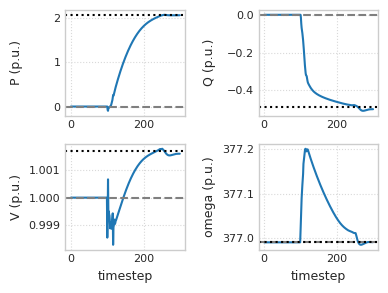

In [56]:
# Plot the objective values (P, Q)
fig = plt.figure(figsize=(4,3))

fp = lambdify((x, param_args), P_grid.subs(sim_subs))
fq = lambdify((x, param_args), Q_grid.subs(sim_subs))
plt.subplot(2,2,1)
plt.plot(fp(xs_sim[:-1, :n, 0].T, np.array(param_t_val_record).T))
plt.axhline(p_ref_val, linestyle='--', color='C7')
plt.axhline(p_opt, linestyle=':', color='k')

plt.ylabel("P (p.u.)")
plt.subplot(2,2,2)
plt.plot(fq(xs_sim[:-1, :n, 0].T, np.array(param_t_val_record).T))
plt.axhline(q_ref_val, linestyle='--', color='C7')
plt.axhline(q_opt, linestyle=':', color='k')
plt.ylabel("Q (p.u.)")
plt.subplot(2,2,3)
plt.plot(us_sim[:, 0, 0])
plt.axhline(1, linestyle='--', color='C7')
plt.axhline(v_opt, linestyle=':', color='k')
plt.ylabel("V (p.u.)")
plt.xlabel("timestep")
plt.subplot(2,2,4)
plt.plot(us_sim[:, 1, 0])
plt.axhline(omega_e_val, linestyle='--', color='C7')
plt.axhline(omega_opt, linestyle=':', color='k')
plt.ylabel("omega (p.u.)")
plt.xlabel("timestep")
fig.align_ylabels()
plt.tight_layout();

fname="outputs.pdf"
plt.savefig(fname, dpi=300, format=None, metadata=None,
        bbox_inches=None, pad_inches=0.0,
        facecolor='auto', edgecolor='auto',
        backend=None
       )


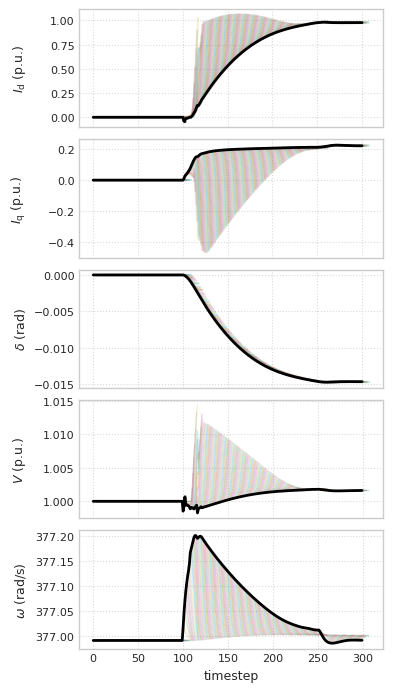

In [57]:
# plot the states and inputs over time
fig = plt.figure(figsize=(4,7))
state_y_labels = [r"$I_\mathrm{d}$ (p.u.)", r"$I_\mathrm{q}$ (p.u.)", r"$\delta$ (rad)"]

axs = []

for i_state in range(n):
  axs.append(plt.subplot(n+m,1,i_state+1))
  plt.plot(xs_sim[:, i_state, 0], lw=2, color='k');

  for i in range(n_steps):
    plt.plot(range(i,i+T), xs[i, i_state:T*n:n, :].reshape((T,1)), marker='', alpha=0.2, zorder=1)
  #plt.ylabel("$"+latex(x[i_state])+"$")
  plt.ylabel(state_y_labels[i_state])

# fig = plt.figure(figsize=(4,4))
input_y_labels = [r"$V$ (p.u.)", r"$\omega$ (rad/s)"]

for i_input in range(m):
  axs.append(plt.subplot(m+n,1,n+i_input+1))
  plt.plot(us_sim[:, i_input, 0], lw=2, color='k');

  #colors = plt.cm.tab20c(np.linspace(0,1,n_steps))
  plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab10.colors)  #TODO: COLORS?

  for i in range(n_steps): #range(0,n_steps,n_steps//50):
    plt.plot(range(i,i+T-1), xs[i, T*n+i_input::m, :].reshape((T-1,1)),
             marker='', alpha=0.2, zorder=1, lw=1)#, color=colors[i])
  #plt.ylabel("$"+latex(u[i_input])+"$")
  plt.ylabel(input_y_labels[i_input])
plt.xlabel("timestep")

[ax.set_xticklabels([]) for ax in axs[:-1]]  # remove x-axis ticks for all but bottom

fig.align_ylabels()
plt.tight_layout();
plt.subplots_adjust(hspace=0.1) # adjust vertical spacing

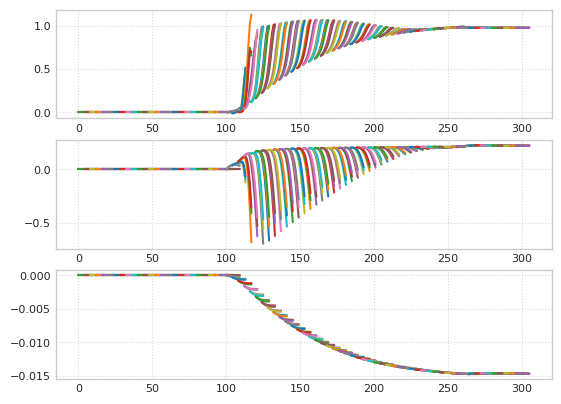

In [58]:
[fig, axs] = plt.subplots(n, 1)
for i in range(0, T_sim, 4):
  for j in range(n):
    axs[j].plot(range(i, i+T), xus_preopt[i, j:T*n:n, :])

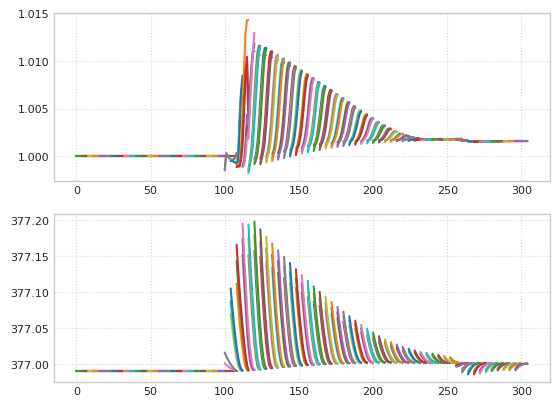

In [59]:
[fig, axs] = plt.subplots(m, 1)
for i in range(0, T_sim, 4):
  for j in range(m):
    axs[j].plot(range(i, T-1+i), xus_preopt[i, n*T+j::m, :])

### MPC controller

In [60]:
try:
  import do_mpc
except:
  !pip install do_mpc
  import do_mpc

from casadi import *
import casadi as cs

/usr/local/lib/python3.12/dist-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/usr/local/lib/python3.12/dist-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


In [61]:
# Set up the system model for the MPC simulations
model_type = 'continuous' # either 'discrete' or 'continuous'
model = do_mpc.model.Model(model_type)

# States:
i_d_ = model.set_variable(var_type='_x', var_name='I_d', shape=(1,1))
i_q_ = model.set_variable(var_type='_x', var_name='I_q', shape=(1,1))
delta_ = model.set_variable(var_type='_x', var_name='delta', shape=(1,1))

# Inputs:
v_ = model.set_variable(var_type='_u', var_name='V')
omega_ = model.set_variable(var_type='_u', var_name='omega')

# Parameters:
r_ = model.set_variable('parameter', 'R')
l_ = model.set_variable('parameter', 'L')
omega_e_ = model.set_variable('parameter', 'omega')
pref_ = model.set_variable('parameter', 'Pref')
qref_ = model.set_variable('parameter', 'Qref')
vref_ = model.set_variable('parameter', 'Vref')
wref_ = model.set_variable('parameter', 'Wref')
e_ = model.set_variable('parameter', 'E')

# Set expression for current magnitude
Idq_mag_ = model.set_expression('I_dq_mag', i_d_**2 + i_q_**2)

P_ = model.set_expression('P', 3/2*(sqrt(2)*e_*cos(delta_) * i_d_ + sqrt(2) * e_*sin(delta_) * i_q_))
Q_ = model.set_expression('Q', 3/2*(sqrt(2)*e_*sin(delta_) * i_d_ - sqrt(2) * e_*cos(delta_) * i_q_))

# Dynamics
v_d_ = sqrt(2)*v_
v_q_ = 0 #v * sin(theta)

e_d_ = sqrt(2)* e_*cos(delta_)
e_q_ = sqrt(2)* e_*sin(delta_)

i_d_dot_ = -r_/l_ * i_d_ + omega_ * i_q_ + 1/l_ * (v_d_ - e_d_)
i_q_dot_ = -r_/l_ * i_q_ - omega_ * i_d_ + 1/l_ * (v_q_ - e_q_)
delta_dot_ = omega_e_ - omega_


model.set_rhs('I_d', i_d_dot_)
model.set_rhs('I_q', i_q_dot_)
model.set_rhs('delta', delta_dot_)

model.setup()

In [62]:
# Set up the MPC controller
mpc = do_mpc.controller.MPC(model)

t_step = delta_t
setup_mpc = {
    'n_horizon': t_horizon, #50, #20,
    't_step': t_step,
    'n_robust': 0,
    'store_full_solution': True,
}
mpc.set_param(**setup_mpc)

# Define the objective
P_grid_ = 3/2* (sqrt(2)* e_*cos(delta_) * i_d_ + sqrt(2)* e_*sin(delta_) * i_q_)
Q_grid_ = 3/2* (sqrt(2)* e_*sin(delta_) * i_d_ - sqrt(2)* e_*cos(delta_) * i_q_)

# lterm = mp_val/2*(P_grid_ - pref_)**2 + (mq_val/tv_val)/2*(Q_grid_ - qref_)**2 + (mv_val/tv_val)/2*(v_ - vref_)**2 + mw_val/2*(omega_ - wref_)**2
lterm = mp_val/2*(P_grid_ - pref_)**2 + (mq_val/tv_val)/2*(Q_grid_ - qref_)**2 + (mv_val/tv_val)/2*(v_ - 1.0)**2 + mw_val/2*(omega_ - omega_base)**2
mterm = mp_val/2*(P_grid_ - pref_)**2 + (mq_val/tv_val)/2*(Q_grid_ - qref_)**2

mpc.set_objective(mterm=mterm, lterm=lterm)

mpc.set_rterm(  # Cost to change input values
    V=1e1,  #1e2
    omega=1e1  #1e2
)

# Set the constraints

mpc.set_nl_cons("I_lim", i_d_**2 + i_q_**2, ub=1**2, soft_constraint=False, penalty_term_cons=100)

# State scaling
mpc.scaling['_x', 'I_d'] = 1
mpc.scaling['_x', 'I_q'] = 1
mpc.scaling['_x', 'delta'] = 1

# Set the time varying paramter values
pref1 = 0* s_base  / s_base
pref2 = param_ref_vals[0]
p_step_time = step_time * t_step

qref1 = 0 * s_base / s_base
qref2 = param_ref_vals[1]

vref1 = v_nom_val / v_base
vref2 = param_ref_vals[2]

wref1 = omega_base
wref2 = param_ref_vals[3]

e1 = param_val0[4]
we1 = param_val0[5]
e2 = param_ref_vals[4]
we2 = param_ref_vals[5]

mpc.set_uncertainty_values(
    R = [sim_subs[r_i]],
    L = [sim_subs[l_i]],
    E = [param_val0[4]],
    omega = [param_val0[5]],
    Pref = [param_val0[0]],
    Qref = [param_val0[1]],
    Vref = [param_val0[2]],
    Wref = [param_val0[3]],
)

mpc.setup()

In [63]:
# Set up the simulator
simulator = do_mpc.simulator.Simulator(model)

simulator.set_param(t_step = t_step)

p_template = simulator.get_p_template()
def p_fun(t_now):
    p_template['R'] = sim_subs[r_i]
    p_template['L'] = sim_subs[l_i]
    p_template['E'] = e1
    p_template['omega'] = we1
    p_template['Pref'] = pref1
    p_template['Qref'] = qref1
    p_template['Vref'] = vref1
    p_template['Wref'] = wref1

    if t_now > p_step_time:
      p_template['E'] = e2
      p_template['omega'] = we2
      p_template['Pref'] = pref2
      p_template['Qref'] = qref2
      p_template['Vref'] = vref2
      p_template['Wref'] = wref2
    return p_template

simulator.set_p_fun(p_fun)

simulator.setup()

In [64]:
# Initial conditions
p_ref_val, q_ref_val = 0 * s_base/s_base, 0 * s_base/s_base # 3x for some reason? Scaling of DQ power calculation?
e_val = 1.
omega_e_val = 2*np.pi*60
param_val0 = [p_ref_val, q_ref_val, e_val, omega_e_val, e_val, omega_e_val]

u0 = np.array([v_nom_val / v_base, omega_e_val])[:, None]
sol = sym.solve(fx.subs(zip(u, u0.flatten())).subs(zip(param_args, param_val0)), x)
x_eq = Matrix(sol[0]).subs(x[2], 0.0)#0.0001)
x0_val = np.array(x_eq).astype(float)
u0_val = np.array(u0).astype(float)
x0_val

array([[0.],
       [0.],
       [0.]])

In [65]:
# Run simulation with MPC controller
x0_val = np.array(x0)  # Copy initial conditions used for STGF controller
u0_val = np.array(u0)
simulator.x0 = x0_val
mpc.x0 = x0_val
mpc.u0 = u0_val

mpc.set_initial_guess()

simulator.reset_history()
simulator.x0 = x0_val
mpc.reset_history()

t_sim = float(T_sim * dt_val)
T_sim_mpc = int(t_sim / t_step)
print(T_sim_mpc)
start_time = time.time()

mpc_solve_times = []

x_sim = np.array(x0_val)
u_sim = np.array(u0_val)
for i in range(T_sim_mpc):
    if i % (T_sim // 10) == 0:
      print("Iter: %s --- %s seconds ---" % (i, time.time() - start_time))
    if i*t_step > p_step_time:
      mpc.set_uncertainty_values(
        R = [sim_subs[r_i]],
        L = [sim_subs[l_i]],
        E = [e2],
        omega = [we2],
        Pref = [pref2],
        Qref = [qref2],
        Vref = [vref2],
        Wref = [wref2],
      )
    #solve_time = time.time()
    u_sim = mpc.make_step(x_sim)
    mpc_solve_times.append(mpc.solver_stats['t_proc_total']) #mpc.solver_stats['t_wall_total'])
    x_sim = simulator.make_step(u_sim)
print("Total time: %s --- %s seconds ---" % (i, time.time() - start_time))

Streaming output truncated to the last 5000 lines.
                     variables with only upper bounds:        0
Total number of equality constraints.................:      123
Total number of inequality constraints...............:       10
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       10

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.1454533e+01 2.31e-02 2.95e+01  -1.0 0.00e+00    -  0.00e+00 0.00e+00   0
   1  9.8472686e+00 1.03e-05 3.00e-01  -1.0 3.87e-01  -4.0 1.00e+00 1.00e+00f  1
   2  9.5593149e+00 4.90e-07 2.22e-02  -1.7 4.07e-02  -4.5 1.00e+00 1.00e+00f  1
   3  9.4431282e+00 1.82e-07 9.07e-03  -2.5 2.15e-02  -5.0 1.00e+00 1.00e+00f  1
   4  9.4187096e+00 3.89e-08 2.83e-03  -3.8 1.22e-02  -5.4 1.00e+00 1.00e+00f  1
   5  9.4163264e+00 5.18e-09 6.60e-04  -3.8 6.86e-03  -5.9 1.00e+00 1.00e+00h 

average solve time:  24.19612333333333  ms
solve time variance:  0.7225625690481222  ms
max solve time:  214.525  ms
min solve time:  9.33  ms


Text(0, 0.5, 'solve time (ms)')

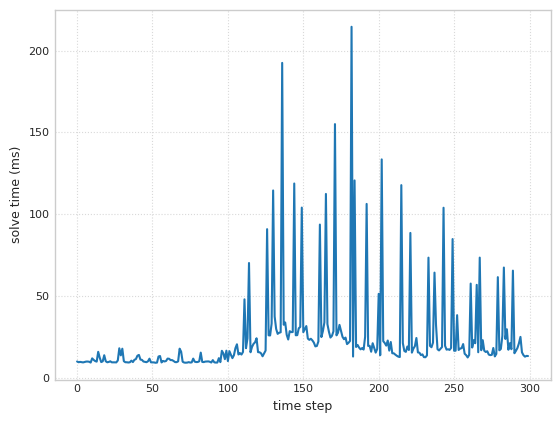

In [66]:
# Check the average solve time
print("average solve time: ", np.mean(np.array(mpc_solve_times))*1000, ' ms')
print("solve time variance: ", np.var(np.array(mpc_solve_times))*1000, ' ms')
print("max solve time: ", np.max(np.array(mpc_solve_times))*1000, ' ms')
print("min solve time: ", np.min(np.array(mpc_solve_times))*1000, ' ms')
plt.plot(np.array(mpc_solve_times)*1000)
plt.xlabel("time step")
plt.ylabel("solve time (ms)")

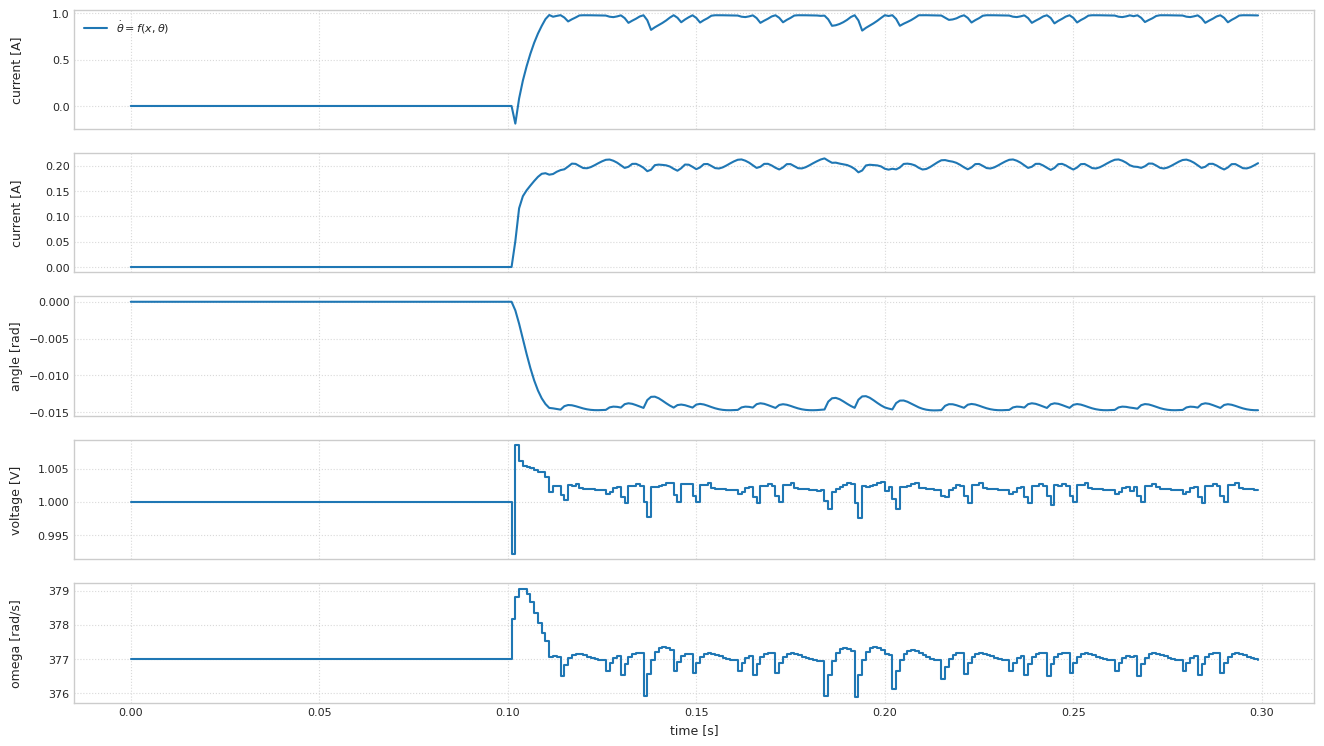

In [67]:
mpc_graphics = do_mpc.graphics.Graphics(mpc.data)
sim_graphics = do_mpc.graphics.Graphics(simulator.data)

fig, ax = plt.subplots(5, sharex=True, figsize=(16,9))
fig.align_ylabels()

for g in [sim_graphics]:
    # Plot the angle positions (phi_1, phi_2, phi_2) on the first axis:
    g.add_line(var_type='_x', var_name='I_d', axis=ax[0])
    g.add_line(var_type='_x', var_name='I_q', axis=ax[1])
    g.add_line(var_type='_x', var_name='delta', axis=ax[2])

    # Plot the set motor positions (phi_m_1_set, phi_m_2_set) on the second axis:
    g.add_line(var_type='_u', var_name='V', axis=ax[3])
    g.add_line(var_type='_u', var_name='omega', axis=ax[4])


ax[0].set_ylabel('current [A]')
ax[1].set_ylabel('current [A]')
ax[2].set_ylabel('angle [rad]')
ax[3].set_ylabel('voltage [V]')
ax[4].set_ylabel('omega [rad/s]')
ax[4].set_xlabel('time [s]')

ax[0].legend([r'$\dot{\theta} = f(x, \theta)$', r'$\dot{\theta} = -i_q$'])

sim_graphics.plot_results()

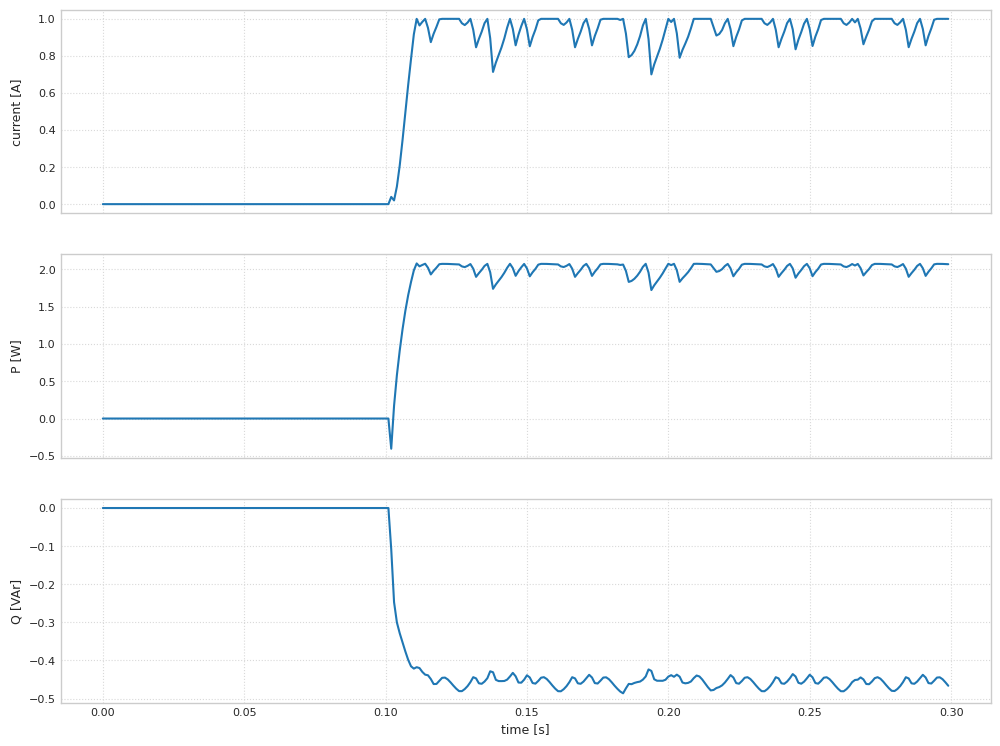

In [68]:
fig, ax = plt.subplots(3, sharex=True, figsize=(12,9))
fig.align_ylabels()

# Make all predictions transparent:
for line_i in mpc_graphics.pred_lines.full: line_i.set_alpha(0.2)

for g in [sim_graphics]:
    # Plot the angle positions (phi_1, phi_2, phi_2) on the first axis:
    g.add_line(var_type='_aux', var_name='I_dq_mag', axis=ax[0])
    g.add_line(var_type='_aux', var_name='P', axis=ax[1])
    g.add_line(var_type='_aux', var_name='Q', axis=ax[2])


ax[0].set_ylabel('current [A]')
ax[1].set_ylabel('P [W]')
ax[2].set_ylabel('Q [VAr]')
ax[2].set_xlabel('time [s]')

# ax.legend([r'$\|I_{dq}\|', r'$P$'])

sim_graphics.plot_results()

### Droop controller

Implement an augemented droop controller with an angle synchronization term proposed in ["Enhanced Large-Signal Stability Method for Grid-Forming Inverters During Current Limiting"](https://ieeexplore.ieee.org/document/10221088/) by Nathan Baeckeland and Gab-Su Seo

In [69]:
class DroopController():
  def __init__(self, v_nom, w_nom, s_rated, mp=None, mq=None, wc=None, pref=0, qref=0):
    """
    vnom: Nominal voltage (V)
    wnom: Nominal frequency (rad)
    mp: Active power droop
    mq: Reactive power droop
    wc: Active power low-pass filter cut-off frequency
    pref: Active power reference (W)
    qref: Reactive power reference (VAr)
    args: Additional arguments that one or more of the expressions contains
    """

    self.V = v_nom
    self.omega = w_nom
    self.p_filt = 0

    self.v_nom = v_nom
    self.w_nom = w_nom
    self.s_rated = s_rated

    self.w_cutoff = 30*2*np.pi if wc is None else wc
    self.mp = (1.0 * 2 * np.pi) / s_rated if mp is None else mp
    self.mq = (0.05 * v_nom) / s_rated if mp is None else mp

    self.p_ref = pref
    self.q_ref = qref

    self.k = 1e3  # Large k ensures that the synchronization term can grow large enough
    self.sigma = 10 # Small sigma leads to a smoother application of the synchronizing force
    self.z = 0.9 # Setting this to be below ilim ensures the synchronization force engages
    self.ilim = 0.95 # Setting ilim to be below the saturation limit ensures the synchronization force engages

  def step(self, x, dt=1e-3, args=[]):
    self.p_ref, self.q_ref = args[0], args[1]
    e_d, e_q = args[2] * np.cos(x[2]), args[2] * np.sin(x[2])
    v_d, v_q = e_d, e_q
    i_d, i_q = x[:2]
    p_ctrl = 3/np.sqrt(2) * (v_d * i_d + v_q * i_q)
    q_ctrl = 3/np.sqrt(2) * (v_q * i_d - v_d * i_q)

    self.p_filt = self.p_filt + dt * self.w_cutoff*(p_ctrl - self.p_filt)

    self.V = self.v_nom - self.mq * (q_ctrl - self.q_ref)
    self.omega = self.w_nom - self.mp * (self.p_filt - self.p_ref)

    # Approach from "Enhanced Large-Signal Stability Method for Grid-Forming Inverters During Current Limiting"
    i_mag = np.linalg.norm(x[:2])
    if i_mag >= 1e-5:  # Only calculate true rho if i_mag is beyond a small tolerance threshold to avoid divide by zero
      rho = np.min([1, self.ilim / np.linalg.norm(x[:2])])
    else:
      rho = 1
    sync_term = self.k / (1 + np.exp(self.sigma * (rho - self.z))) * np.atan(e_q / e_d)
    sync_term_zero = self.k / (1 + np.exp(self.sigma * (1 - self.z))) * np.atan(e_q / e_d)  # Cancels out the sync_term value when below the threshold
    return np.array([self.V, self.omega + sync_term - sync_term_zero])

In [70]:
droop = DroopController(1., omega_base, 1.)
param_val0 = [0.0, 0.0, 1.0, omega_base, 1.0, omega_base]

In [71]:
# Determine feasible initial conditions
p_ref_val, q_ref_val = 0*1500 / s_base, 0 / s_base
e_val = 1.
omega_nom_val = 2*np.pi*60
param_val0 = [p_ref_val, q_ref_val, e_val, omega_nom_val, e_val, omega_nom_val, mp_val, mq_val, mv_val, mw_val]

u0 = np.array([v_nom_val / v_base, omega_e_val])[:, None]
sol = sym.solve(fx.subs(zip(u, u0.flatten())).subs(zip(param_args, param_val0)), x)
x_eq = Matrix(sol[0]).subs(x[2], 0.000)
x0 = np.array(x_eq).astype(float)
x0

array([[0.],
       [0.],
       [0.]])

Iter: 0 --- 0.0013256072998046875 seconds ---
Iter: 30 --- 0.022220849990844727 seconds ---
Iter: 60 --- 0.04439687728881836 seconds ---
Iter: 90 --- 0.0644221305847168 seconds ---

Stepping Pref, Qref
Iter: 120 --- 0.08025312423706055 seconds ---
Iter: 150 --- 0.09621500968933105 seconds ---
Iter: 180 --- 0.1115560531616211 seconds ---
Iter: 210 --- 0.12231206893920898 seconds ---
Iter: 240 --- 0.13210463523864746 seconds ---
Iter: 270 --- 0.14163780212402344 seconds ---


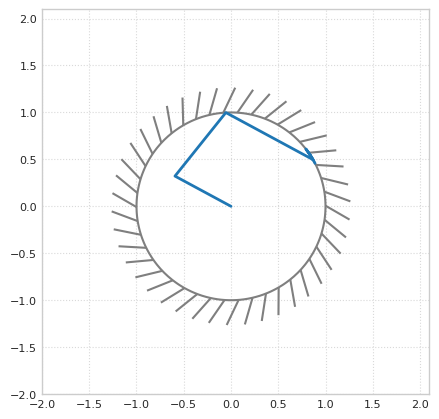

In [72]:
from scipy.integrate import solve_ivp

def simfx(t, x, u, param):
  return f(x, u, param).flatten()

solver.verbose=False

n_steps = T_sim
i_sat = 1.0

param_vals = list(param_val0)

# Initialize simulation values
xs_sim_droop = np.zeros((n_steps+1, *x0.shape))
us_sim_droop = np.zeros((n_steps, *u0.shape))

xu0 = np.zeros((T*n+(T-1)*m, 1))
xu0[0:n, :] = x0
xu0[n*T:n*T+m] = u0
for t in range(T-1):
  xu0[n*T+m*t:n*T+m*(t+1)] = u0  # Useful for using some nominal controller to stabalize the system?
  xu0[n*(t+1):n*(t+2)] = xu0[n*t:n*(t+1)] + dt*f(x0.flatten(), u0.flatten(), param_vals)

n_iters = 1

start_time = time.time()
droop_solve_times = []

xs = np.zeros((n_steps+1, T*n+(T-1)*m, 1))
xs[0] = xu0

xs_sim_droop[0] = np.array(x0)
us_sim_droop[0] = np.array(u0)
for i in range(n_steps):
  if i % (n_steps // 10) == 0:
    print("Iter: %s --- %s seconds ---" % (i, time.time() - start_time))

  # Step parameters (known disturbances)
  if i == step_time:
    print("")
    print("Stepping Pref, Qref")
    param_vals = [*param_ref_vals]

  solve_time = time.time()

  u_ctrl = droop.step(xs_sim_droop[i, :, 0], dt, args=param_vals)

  droop_solve_times.append(time.time() - solve_time)

  # Apply control action to the simulated system
  us_sim_droop[i] = u_ctrl[:, None]
  ivp_sol = solve_ivp(simfx, (i*dt,(i+1)*dt), xs_sim_droop[i].flatten(), args=(us_sim_droop[i].flatten(), param_vals))
  xs_sim_droop[i+1] = ivp_sol.y[:, -1:]

  # Immitate inner current control loop with circular reference saturation
  i_mag = np.linalg.norm(xs_sim_droop[i+1, :2, 0])
  if i_mag > i_sat:  # Saturate current if it is above 1.0 p.u.
    xs_sim_droop[i+1, :2, 0] = xs_sim_droop[i+1, :2, 0] * i_sat / i_mag

fig = plt.figure(figsize=(5,5))
plt.plot(xs_sim_droop[:, 0, 0], xs_sim_droop[:, 1, 0], linewidth=2.0, zorder=4);
y_domain, x_domain = (-2, 2), (-2, 2)
plot_2d_constraints(gx[0, :], Matrix(xt[:2, 1]), y_domain, x_domain);

plt.ylim(-2, 2.1);
plt.xlim(-2, 2.1);

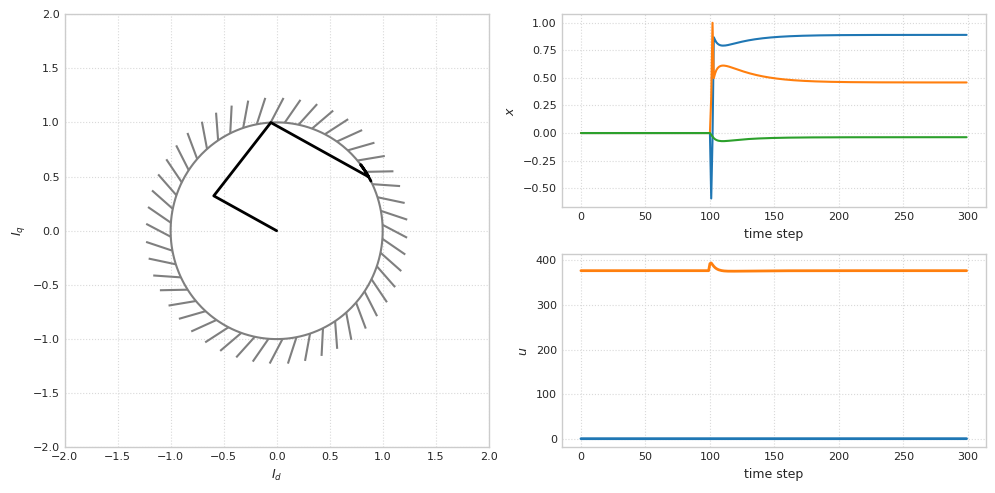

In [73]:
xus_sim = np.hstack([xs_sim_droop[:-1], us_sim_droop])
ax = plot_results(xus_sim, T=1, gx=gx[0, :], xt=Matrix(xt[:2, 1]), plot_traj=False)#, y_domain=[-4, 2], x_domain=[-2, 4]); # If n > 2 and constraints are on <= 2 states

ax[0].set_xlabel("$I_d$")
ax[0].set_ylabel("$I_q$")
ax[1].set_ylabel("$x$")
ax[1].set_xlabel("time step")
ax[2].set_ylabel("$u$")
ax[2].set_xlabel("time step")
plt.tight_layout()

fname="full-trajectory.pdf"
plt.savefig(fname, dpi=300, format=None, metadata=None,
        bbox_inches=None, pad_inches=0.0,
        facecolor='auto', edgecolor='auto',
        backend=None
       )

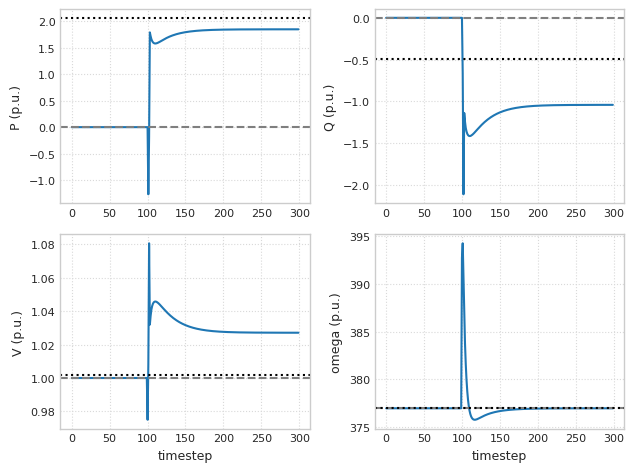

In [74]:
# Plot the objective values (P, Q)
# fig = plt.figure(figsize=(4,3))

fp = lambdify((x, param_args), P_grid.subs(sim_subs))  # TODO: add param_args and values here
fq = lambdify((x, param_args), Q_grid.subs(sim_subs))
plt.subplot(2,2,1)
plt.plot(fp(xus_sim[:, :n, 0].T, param_vals))
plt.axhline(p_ref_val, linestyle='--', color='C7')
plt.axhline(p_opt, linestyle=':', color='k')

plt.ylabel("P (p.u.)")
plt.subplot(2,2,2)
plt.plot(fq(xus_sim[:, :n, 0].T, param_vals))
plt.axhline(q_ref_val, linestyle='--', color='C7')
plt.axhline(q_opt, linestyle=':', color='k')
plt.ylabel("Q (p.u.)")
plt.subplot(2,2,3)
plt.plot(xus_sim[:, 1*n:1*n+1, 0])
plt.axhline(1, linestyle='--', color='C7')
plt.axhline(v_opt, linestyle=':', color='k')
plt.ylabel("V (p.u.)")
plt.xlabel("timestep")
plt.subplot(2,2,4)
plt.plot(xus_sim[:, 1*n+1:1*n+2, 0])
plt.axhline(omega_e_val, linestyle='--', color='C7')
plt.axhline(omega_opt, linestyle=':', color='k')
plt.ylabel("omega (p.u.)")
plt.xlabel("timestep")
fig.align_ylabels()
plt.tight_layout();

fname="outputs.pdf"
plt.savefig(fname, dpi=300, format=None, metadata=None,
        bbox_inches=None, pad_inches=0.0,
        facecolor='auto', edgecolor='auto',
        backend=None
       )

average solve time:  0.04520575205485026  ms
solve time variance:  1.0281351756526014e-06  ms
max solve time:  0.47087669372558594  ms
min solve time:  0.026226043701171875  ms


Text(0, 0.5, 'solve time (ms)')

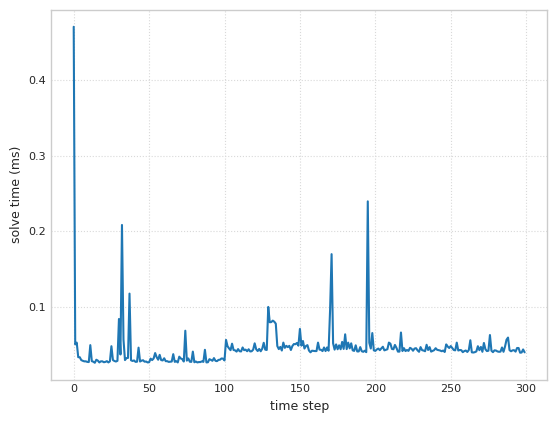

In [75]:
# Check the average solve time
print("average solve time: ", np.mean(np.array(droop_solve_times))*1000, ' ms')
print("solve time variance: ", np.var(np.array(droop_solve_times))*1000, ' ms')
print("max solve time: ", np.max(np.array(droop_solve_times))*1000, ' ms')
print("min solve time: ", np.min(np.array(droop_solve_times))*1000, ' ms')
plt.plot(np.array(droop_solve_times)*1000)
plt.xlabel("time step")
plt.ylabel("solve time (ms)")

## Compare Controllers

In [76]:
# Create array of time steps
ts = np.arange(0, delta_t*(T_sim+1), delta_t)

# Gather STGF Data
x_stgf = xs_sim
u_stgf = us_sim

# Get MPC Data
x_mpc = simulator.data['_x']
u_mpc = simulator.data['_u']

# Get Droop Controller Data
x_droop = xs_sim_droop
u_droop = us_sim_droop

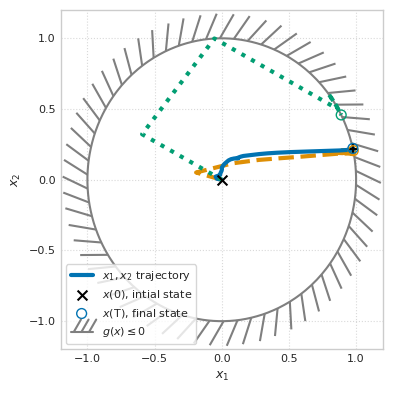

In [77]:
# Replot the trajectory for saving
sns_cb = sns.color_palette("colorblind")
ctrl_colors = {"STGF": sns_cb[0],
               "MPC": sns_cb[1],
               "droop": sns_cb[2],
               }

fig = plt.figure(figsize=(4,4))
traj_line = plt.plot(x_stgf[:, 0], x_stgf[:, 1], lw=3, color=ctrl_colors["STGF"], zorder=3);
y_domain, x_domain = (-2, 2), (-2, 2)
contour = plot_2d_constraints(gx[0, :], Matrix(xt[:2, 1]), y_domain, x_domain);
x0_mark = plt.scatter(x_stgf[0, 0], x_stgf[0, 1], marker='x', color='k',s=50, zorder=6)
xf_mark = plt.scatter(x_stgf[-1, 0], x_stgf[-1, 1], marker='o', facecolor='none', edgecolor=ctrl_colors["STGF"],s=50, zorder=6)

xstar_mark = plt.scatter(x_opt[0], x_opt[1], marker='+', color='k',s=50, zorder=5)

mpc_traj_line = plt.plot(x_mpc[:, 0], x_mpc[:, 1], lw=3, color=ctrl_colors["MPC"], linestyle='--', zorder=2);
xf_mpc = plt.scatter(x_mpc[-1, 0], x_mpc[-1, 1], marker='o', facecolor='none', edgecolor=ctrl_colors["MPC"],s=50, zorder=5)
droop_traj_line = plt.plot(x_droop[:, 0], x_droop[:, 1], lw=3, color=ctrl_colors["droop"], linestyle=':', zorder=4);
xf_droop = plt.scatter(x_droop[-1, 0, 0], x_droop[-1, 1, 0], marker='o', facecolor='none', edgecolor=ctrl_colors["droop"],s=50, zorder=5)


import matplotlib.lines as mlines
c_line = mlines.Line2D([], [], color='C7',
                          markersize=20, label='Blue stars')
c_line.set(path_effects=[patheffects.withTickedStroke(angle=60, length=2, spacing=5.)])

plt.legend([traj_line[0], x0_mark, xf_mark, c_line],
 [r"$x_{1}, x_{2}$ trajectory", r"$x(0)$, intial state", r"$x(\mathrm{T})$, final state", r"$g(x) \leq 0$"], frameon=True)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")

plt.ylim(-1.2, 1.2);
plt.xlim(-1.2, 1.2);
plt.tight_layout();

fname="trajectory.pdf"
plt.savefig(fname, dpi=300, format=None, metadata=None,
        bbox_inches=None, pad_inches=0.0,
        facecolor='auto', edgecolor='auto',
        backend=None
       )

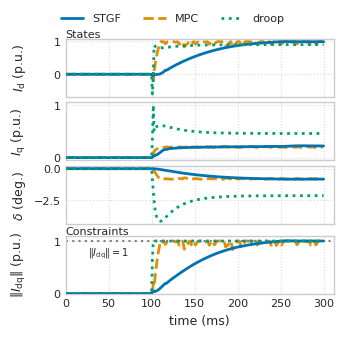

In [78]:
# Plot the states and inputs over time
import matplotlib.gridspec as gridspec

xlim1, xlim2 = ts[0]*1000, ts[-1]*1.04*1000
state_y_labels = [r"$I_\mathrm{d}$ (p.u.)", r"$I_\mathrm{q}$ (p.u.)", r"$\delta$ (deg.)"]

n_states = n
n_inputs = m
n_constraints = 1
num_x_plots = [n, 1, m]
plot_states = True
plot_inputs = False
plot_constraints = True
plot_bools = [plot_states, plot_constraints, plot_inputs]

n_row = np.sum([n for n, to_plot in zip(num_x_plots, plot_bools)])
fig = plt.figure(figsize=(3.5,0.68*n_row + 0.01*np.sum(plot_bools)))
gs = gridspec.GridSpec(n_row, 1, figure=fig, hspace=0.1)

axs = []
if plot_states:
  for i_state in range(n):
    if i_state == 2:
      scale = 180 / np.pi
    else:
      scale = 1

    axs.append(plt.subplot(n_row,1,i_state+1))
    plt.plot(ts*1000, x_stgf[:, i_state, 0] * scale, lw=2, color=ctrl_colors["STGF"], zorder=3, label="STGF");
    plt.plot(ts[:-1]*1000, x_mpc[:, i_state] * scale, lw=2, linestyle='--', color=ctrl_colors["MPC"], label="MPC");
    plt.plot(ts*1000, x_droop[:, i_state] * scale, lw=2, linestyle=':', color=ctrl_colors["droop"], zorder=4, label="droop");

    # Plot planned trajectories
    # for i in range(n_steps):
    #   plt.plot(range(i,i+T), xs[i, i_state:T*n:n, :].reshape((T,1)), marker='', alpha=0.2, zorder=1)
    #plt.ylabel("$"+latex(x[i_state])+"$")
    plt.ylabel(state_y_labels[i_state])
    plt.xlim(xlim1, xlim2)

# fname="states.pdf"
# plt.savefig(fname, dpi=300, format=None, metadata=None,
#         bbox_inches=None, pad_inches=0.0,
#         facecolor='auto', edgecolor='auto',
#         backend=None
#        )

if plot_constraints:
  axs.append(plt.subplot(n_row,1,n+1))

  # Plot Idq magnitude
  plt.plot(ts*1000, np.linalg.norm(x_stgf[:, :2, 0], axis=1), lw=2, color=ctrl_colors["STGF"], zorder=3);
  plt.plot(ts[:-1]*1000, np.linalg.norm(x_mpc[:, :2], axis=1), lw=2, linestyle='--', color=ctrl_colors["MPC"]);
  plt.plot(ts*1000, np.linalg.norm(x_droop[:, :2], axis=1), lw=2, linestyle=':', color=ctrl_colors["droop"], zorder=4);
  plt.xlim(xlim1, xlim2)

  lim_line = plt.axhline(1.0, linestyle=(0, (1,2)), color='C7', label=r"$\| I_\mathrm{dq} \| = 1$")
  plt.ylabel(r"$\| I_\mathrm{dq} \|$ (p.u.)")
  # axs[-1].legend(frameon=True)
  plt.text(step_time // 2, 0.9, r"$\| I_\mathrm{dq} \| = 1$", fontsize=7, ha='center', va='top')
  plt.ylim(0, 1.1)

if plot_inputs:
  for i_input in range(m):
    axs.append(plt.subplot(n_row,1,n+i_input+2))

    if i_input == 1:
      scale = 1 / omega_nom_val
    else:
      scale = 1
    plt.plot(ts[:-1]*1000, u_stgf[:, i_input, 0] * scale, lw=2, color=ctrl_colors["STGF"], zorder=3);
    plt.plot(ts[:-1]*1000, u_mpc[:, i_input] * scale, lw=2, linestyle='--', color=ctrl_colors["MPC"]);
    plt.plot(ts[:-1]*1000, u_droop[:, i_input] * scale, lw=2, linestyle=':', color=ctrl_colors["droop"], zorder=4);

    # Plot STGF input trajectories
    # for i in range(n_steps): #range(0,n_steps,n_steps//50):
    #   plt.plot(range(i,i+T-1), xs[i, T*n+i_input::m, :].reshape((T-1,1)),
    #            marker='', alpha=0.2, zorder=1, lw=1)#, color=colors[i])
    #plt.ylabel("$"+latex(u[i_input])+"$")
    plt.ylabel(input_y_labels[i_input])
    plt.xlim(xlim1, xlim2)
  axs[-2].set_ylim([v_base / v_base - 0.01, v_base / v_base + 0.05])
  axs[-1].set_ylim([omega_base / omega_base - 0.01, omega_base / omega_base + 0.01])

plt.xlabel("time (ms)")

[ax.set_xticklabels([]) for ax in axs[:-1]]  # remove x-axis ticks for all but bottom

ax_idxs = [0, n_states, n_states+n_constraints]
axs[ax_idxs[0]].text(0, 1.16, "States", fontsize=8, ha='left', va='top', transform=axs[0].transAxes) if plot_states else None
axs[ax_idxs[1]].text(0, 1.16, "Constraints", fontsize=8, ha='left', va='top', transform=axs[n].transAxes) if plot_constraints else None
axs[ax_idxs[2]].text(0, 1.16, "Inputs", fontsize=8, ha='left', va='top', transform=axs[n+1].transAxes) if plot_inputs else None

plt.tight_layout();
plt.subplots_adjust(hspace=0.1) # adjust vertical spacing

plots_to_shift = [0]
for i, plotted in enumerate(plot_bools):
  if plotted:
    plots_to_shift.append(plots_to_shift[-1] + num_x_plots[i])

for i in plots_to_shift[:-1]:
  for j in range(i, len(axs)):
    pos = axs[j].get_position()
    axs[j].set_position([pos.x0, pos.y0 - 0.015, pos.width, pos.height])


fig.legend(*axs[0].get_legend_handles_labels(), frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.02),
          ncol=3, alignment='center')

fig.align_ylabels()


# fname="states_constraints_inputs.pdf"
# plt.savefig(fname, dpi=300, format=None, metadata=None,
#         bbox_inches='tight', pad_inches=0.0,
#         facecolor='auto', edgecolor='auto',
#         backend=None
#        )

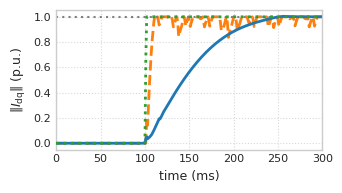

In [79]:
# Plot the current magnitude over time
fig = plt.figure(figsize=(3.5,2))

plt.plot(ts*1000, np.linalg.norm(x_stgf[:, :2, 0], axis=1), lw=2, color='C0', zorder=3);
plt.plot(ts[:-1]*1000, np.linalg.norm(x_mpc[:, :2], axis=1), lw=2, linestyle='--', color='C1');
plt.plot(ts*1000, np.linalg.norm(x_droop[:, :2], axis=1), lw=2, linestyle=':', color='C2', zorder=4);
plt.xlim(plt.xlim(ts[0]*1000, ts[-1]*1000))

plt.axhline(1.0, linestyle=(0, (1,2)), color='C7')

plt.xlabel("time (ms)")
plt.ylabel(r"$\| I_\mathrm{dq} \|$ (p.u.)")
plt.tight_layout();

fname="current-magnitude.pdf"
plt.savefig(fname, dpi=300, format=None, metadata=None,
        bbox_inches=None, pad_inches=0.0,
        facecolor='auto', edgecolor='auto',
        backend=None
       )

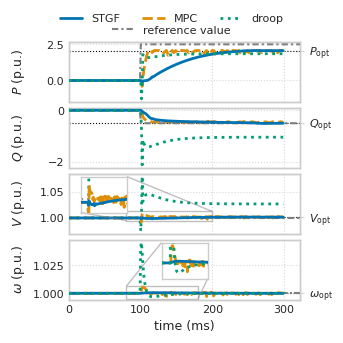

In [80]:
# Plot the objective values (P, Q)
fig = plt.figure(figsize=(3.5,0.8*4))
xlim1, xlim2 = ts[0]*1000, ts[-1]*1.075*1000
n_row = 4
n_col = 1
axs = []

plot_param_vals = np.array(param_t_val_record).T
plot_param_vals_ = np.hstack([plot_param_vals, np.repeat(plot_param_vals[:, -1:], 100, axis=1)])  # Copy end points to past the sim time
plot_opt_vals = plot_param_vals[:4, 0:1] * np.ones([4, T_sim])
plot_opt_vals[0, step_time:] = p_opt
plot_opt_vals[1, step_time:] = q_opt
plot_opt_vals[2, step_time:] = v_opt
plot_opt_vals[3, step_time:] = omega_opt


fp = lambdify((x, param_args), P_grid.subs(sim_subs))  # TODO: add param_args and values here
fq = lambdify((x, param_args), Q_grid.subs(sim_subs))
ax1 = plt.subplot(n_row, n_col,1)
plt.plot(fp(x_stgf[:-1, :n, 0].T, plot_param_vals), zorder=3, lw=2, label="STGF", color=ctrl_colors["STGF"])
plt.plot(fp(x_mpc.T, plot_param_vals), linestyle='--', zorder=2, lw=2, label="MPC", color=ctrl_colors["MPC"])
plt.plot(fp(x_droop[:-1, :n, 0].T, plot_param_vals), linestyle=':', zorder=4, lw=2, label="droop", color=ctrl_colors["droop"])

plt.plot(plot_param_vals_[0, :], linestyle=(0, (3, 1.5, 1, 1.5)), color='C7', linewidth=1.5, label="reference value")
# plt.axhline(p_opt, linestyle=(0, (1, 2)), xmin= 0.225, color='C3', alpha=0.9, label="optimal value")
# ax1.annotate(r"$P_\mathrm{opt}$", xy=(T_sim, p_opt), xytext=(T_sim*1.15, p_opt), ha='center', va='center',
#              arrowprops=dict(facecolor='black', linewidth=1, arrowstyle='-|>'),)
plt.ylabel(r"$P$ (p.u.)")
plt.xlim(xlim1, xlim2)
ax2 = ax1.twinx()
ax2.set_yticks([float(p_opt)], [r"$P_\mathrm{opt}$"])
# ax2.tick_params(axis=u'both', which=u'both',length=5)
gridline = ax1.get_ygridlines()[0]
style = {
    'color': 'k',#gridline.get_color(),
    'linestyle': gridline.get_linestyle(),
    'linewidth': gridline.get_linewidth(),
    'alpha': gridline.get_alpha(),
}
ax2.tick_params(axis=u'y', which=u'both', direction='inout', length=6, width=1, color=gridline.get_color())
ax2.set_ylim(ax1.get_ylim())
ax2.grid()
ax2.set_zorder(ax1.get_zorder() - 1)
ax1.patch.set_visible(False)
ax2.axhline(p_opt, **style, label="optimal value")#, xmin= 0.225)
axs.append(ax1)


ax = plt.subplot(n_row, n_col,2)
plt.plot(fq(x_stgf[:-1, :n, 0].T, plot_param_vals), linestyle='-', zorder=3, lw=2, color=ctrl_colors["STGF"])
plt.plot(fq(x_mpc.T, plot_param_vals), linestyle='--', zorder=2, lw=2, color=ctrl_colors["MPC"])
plt.plot(fq(x_droop[:-1, :n, 0].T, plot_param_vals), linestyle=':', zorder=4, lw=2, color=ctrl_colors["droop"])
plt.plot(plot_param_vals_[1, :], linestyle=(0, (3, 1.5, 1, 1.5)), color='C7', linewidth=1.5, label="reference value")
# plt.plot(plot_opt_vals[1, step_time:], linestyle=(0, (1, 2)), color='C3')
# ax.annotate(r"$Q_\mathrm{opt}$", xy=(T_sim, q_opt), xytext=(T_sim*1.15, q_opt), ha='center', va='center',
#              arrowprops=dict(facecolor='black', linewidth=1, arrowstyle='-|>'),)
plt.ylabel(r"$Q$ (p.u.)")
plt.xlim(xlim1, xlim2)
ax2 = ax.twinx()
ax2.set_yticks([float(q_opt)], [r"$Q_\mathrm{opt}$"])
ax2.tick_params(axis=u'y', which=u'both', direction='inout', length=6, width=1, color=gridline.get_color())
ax2.set_ylim(ax.get_ylim())
ax2.grid()
ax2.set_zorder(ax.get_zorder() - 1)
ax.patch.set_visible(False)
ax2.axhline(q_opt, **style, label="optimal value")#, xmin= 0.225)
axs.append(ax)

ax = plt.subplot(n_row, n_col,3)
plt.plot(u_stgf[:, 0, 0], linestyle='-', zorder=4, lw=2, color=ctrl_colors["STGF"])
plt.plot(u_mpc[:, 0].T, linestyle='--', zorder=3, lw=2, color=ctrl_colors["MPC"])
plt.plot(u_droop[:, 0, 0], linestyle=':', zorder=2, lw=2, color=ctrl_colors["droop"])
#plt.ylim(1 - 0.02, 1 + 0.03)
# plt.ylim(top=1.1)
plt.plot(plot_param_vals_[2, :], linestyle=(0, (3, 1.5, 1, 1.5)), color='C7', linewidth=1.5, label="reference value")
# plt.plot(plot_opt_vals[2, :], linestyle=(0, (1, 2)), color='C3')
# ax.annotate(r"$V_\mathrm{opt}$", xy=(T_sim, v_opt), xytext=(T_sim*1.15, v_opt), ha='center', va='center',
#              arrowprops=dict(facecolor='black', linewidth=1, arrowstyle='-|>'),)
plt.ylabel(r"$V$ (p.u.)")
plt.xlim(xlim1, xlim2)
ax2 = ax.twinx()
ax2.set_yticks([float(v_opt)], [r"$V_\mathrm{opt}$"])
ax2.tick_params(axis=u'y', which=u'both', direction='inout', length=6, width=1, color=gridline.get_color())
ax2.set_ylim(ax.get_ylim())
ax2.grid()
ax2.set_zorder(ax.get_zorder() - 1)
ax.patch.set_visible(False)
ax2.axhline(v_opt, **style, label="optimal value")#, xmin= 0.225)
axs.append(ax)

ax = plt.subplot(n_row, n_col,4)
plt.plot(u_stgf[:, 1, 0] / omega_base, linestyle='-', zorder=3, lw=2, color=ctrl_colors["STGF"])
plt.plot(u_mpc[:, 1] / omega_base, linestyle='--', zorder=2, lw=2, color=ctrl_colors["MPC"])
plt.plot(u_droop[:, 1, 0] / omega_base, linestyle=':', zorder=4, lw=2, color=ctrl_colors["droop"])
plt.plot(plot_param_vals_[3, :] / omega_base, linestyle=(0, (3, 1, 1, 1)), color='C7', linewidth=1.5, label="reference value")
# plt.plot(plot_opt_vals[3, :] / omega_base, linestyle=(0, (1, 2)), color='C3')
# ax.annotate(r"$\omega_\mathrm{opt}$", xy=(T_sim, omega_opt / omega_base), xytext=(T_sim*1.15, omega_opt / omega_base), ha='center', va='center',
#              arrowprops=dict(facecolor='black', linewidth=1, arrowstyle='-|>'),)
# plt.ylim(top=1.1)
plt.ylabel(r"$\omega$ (p.u.)")
plt.xlabel("time (ms)")
plt.xlim(xlim1, xlim2)
ax2 = ax.twinx()
ax2.set_yticks([float(omega_opt / omega_base)], [r"$\omega_\mathrm{opt}$"])
ax2.tick_params(axis=u'y', which=u'both', direction='inout', length=6, width=1, color=gridline.get_color())
ax2.set_ylim(ax.get_ylim())
ax2.grid()
ax2.set_zorder(ax.get_zorder() - 1)
ax.patch.set_visible(False)
ax2.axhline(omega_opt / omega_base, **style, label="optimal value")#, xmin= 0.225)
axs.append(ax)

fig.align_ylabels()

[ax.set_xticklabels([]) for ax in axs[:-1]]  # remove x-axis ticks for all but bottom
plt.tight_layout();
plt.subplots_adjust(hspace=0.1) # adjust vertical spacing

# Zoom inset axis of voltage
axinv = axs[2].inset_axes([0.05, 0.35, 0.2, 0.6])   # Inset location
axinv.axis([step_time-20, step_time+100, 0.995, 1.0125])  # Zoom location
axinv.plot(u_stgf[:, 0, 0], linestyle='-', zorder=4, lw=2, color=ctrl_colors["STGF"])
axinv.plot(u_mpc[:, 0].T, linestyle='--', zorder=3, lw=2, color=ctrl_colors["MPC"])
axinv.plot(u_droop[:, 0, 0], linestyle=':', zorder=2, lw=2, color=ctrl_colors["droop"])
axinv.axhline(v_opt, linestyle=(0, (1, 2)), color='C7')
axinv.set_xticks([])
axinv.set_yticks([])
mark_inset(axs[2], axinv, loc1=1, loc2=3, fc="none", ec="0.5", alpha=0.5)  # Draw connecting lines

# Zoom inset axis of frequency
axins = axs[3].inset_axes([0.4, 0.35, 0.2, 0.6])   # Inset location
axins.axis([step_time-20, step_time+80, 0.995, 1.0065])  # Zoom location
axins.plot(u_stgf[:, 1, 0] / omega_base, linestyle='-', zorder=3, lw=2, color=ctrl_colors["STGF"])
axins.plot(u_mpc[:, 1] / omega_base, linestyle='--', zorder=2, lw=2, color=ctrl_colors["MPC"])
axins.plot(u_droop[:, 1, 0] / omega_base, linestyle=':', zorder=4, lw=2, color=ctrl_colors["droop"])
# axins.axhline(omega_e_val / omega_base, linestyle='--', color='C7')
# axins.axhline(omega_opt / omega_base, linestyle=(0, (1, 2)), color='C3')
axins.set_xticks([])
axins.set_yticks([])
mark_inset(axs[3], axins, loc1=2, loc2=4, fc="none", ec="0.5", alpha=0.5)  # Draw connecting lines

# axs[0].axhspan(p_opt-0.2, p_opt+0.2, alpha=0.5, color='C3')
# rect = axs[0].fill_between(np.linspace(step_time, T_sim*1.05, 100), float(p_opt-0.05), float(p_opt+0.05), alpha=0.3, color='C3', label='optimal value')

# ax1.legend(["STGF", "MPC", "droop", "ref.", "optimal"], loc='upper center', bbox_to_anchor=(0.5, 1.5),
#           ncol=3, fancybox=True, shadow=True)
order1=[0, 1, 2]#[0,3,1,4,2]
order2=[3]#, 4]
h, l = ax1.get_legend_handles_labels()
fig.legend([h[idx] for idx in order1],[l[idx] for idx in order1], loc='upper center', bbox_to_anchor=(0.5, 1.07),  # (0.5, 1.125)
          ncol=3, frameon=False, alignment='center')
fig.legend([h[idx] for idx in order2],[l[idx] for idx in order2], loc='upper center', bbox_to_anchor=(0.5, 1.035),  # (0.5, 1.075)
          ncol=3, frameon=False, alignment='center')


# fname="outputs.pdf"
# plt.savefig(fname, dpi=300, format=None, metadata=None,
#         bbox_inches='tight', pad_inches=0.0,
#         facecolor='auto', edgecolor='auto',
#         backend=None
#        )

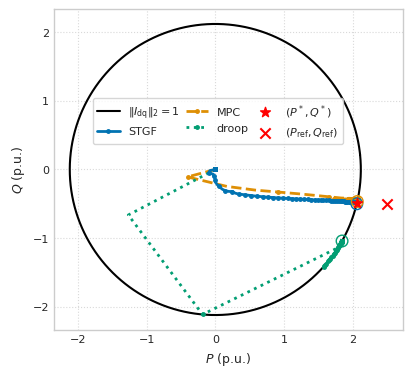

In [81]:
# Plot feasible active & reactive power, and voltage regions
fig = plt.figure(figsize=(4.5, 4.5))

n_rads = 1000
rads = np.linspace(0, 2*pi, n_rads)
idq_feas = np.array([np.cos(rads), np.sin(rads)])
x_feas = np.zeros([n, n_rads])
x_feas[:2, :] = idq_feas
x_feas[2, :] = 0.1  # delta angle difference rotates the feasible space

P_feas = fp(x_feas, param_vals)
Q_feas = fq(x_feas, param_vals)
#V2_feas = fv(x_feas, param_vals)  # Only useful when calculating power injected at inverter terminals

param_t_vals = np.array(param_t_val_record).T

# Mark optimal and reference points
# fig = plt.figure(figsize=(5,4))
plt.plot(P_feas, Q_feas, color='k');

plt.plot(fp(x_stgf[:-1, :n, 0].T, param_t_vals), fq(x_stgf[:-1, :n, 0].T, param_t_vals), lw=2, linestyle='-', zorder=3, marker='.', markersize=5, markevery=3, color=ctrl_colors["STGF"])
plt.plot(fp(x_mpc.T, param_t_vals), fq(x_mpc.T, param_t_vals), lw=2, linestyle='--', zorder=2, marker='.', markersize=5, markevery=3, color=ctrl_colors["MPC"])
plt.plot(fp(x_droop[:-1, :n, 0].T, param_t_vals), fq(x_droop[:-1, :n, 0].T, param_t_vals), lw=2, linestyle=':', marker='.', markersize=5, markevery=3, color=ctrl_colors["droop"])

plt.scatter(p_opt, q_opt, marker='*', color='r',s=55, zorder=6);
plt.scatter(param_ref_vals[0], param_ref_vals[1], marker='x', color='r',s=55, zorder=4);

plt.scatter(fp(x_stgf[:-1, :n, 0].T, param_t_vals)[-1], fq(x_stgf[:-1, :n, 0].T, param_t_vals)[-1], marker='o', facecolor='none',s=70, zorder=5, edgecolor=ctrl_colors["STGF"])
plt.scatter(fp(x_mpc.T, param_t_vals)[-1], fq(x_mpc.T, param_t_vals)[-1], marker='o', facecolor='none',s=70, zorder=5, edgecolor=ctrl_colors["MPC"])
plt.scatter(fp(x_droop[:-1, :n, 0].T, param_t_vals)[-1], fq(x_droop[:-1, :n, 0].T, param_t_vals)[-1], marker='o', facecolor='none',s=70, zorder=5, edgecolor=ctrl_colors["droop"])

plt.legend([r"$\| I_\mathrm{dq} \|_2 = 1$", "STGF", "MPC", "droop", r"$(P^*, Q^*)$", r"$(P_\mathrm{ref}, Q_\mathrm{ref})$"],
           frameon=True, ncol=3, columnspacing=0.5, bbox_to_anchor=(0.47,0.74), loc="upper center")
plt.xlabel("$P$ (p.u.)")
plt.ylabel("$Q$ (p.u.)")
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')

fname="output-trajectory.pdf"
plt.savefig(fname, dpi=300, format=None, metadata=None,
        bbox_inches='tight', pad_inches=0.0,
        facecolor='auto', edgecolor='auto',
        backend=None
       )

Controller: 			 STGF 					 MPC, 					 droop
average solve time: 	 0.5311549200000001  ms 	 24.19612333333333  ms 	 0.04520575205485026  ms
solve time variance: 	 3.4830363517753595e-05  ms 	 0.7225625690481222  ms 	 1.0281351756526014e-06  ms
max solve time: 		 2.4420509999999997  ms 	 214.525  ms 	 0.47087669372558594  ms
min solve time: 		 0.43777699999999997  ms 	 9.33  ms 	 0.026226043701171875  ms


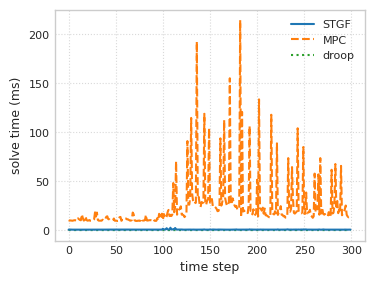

In [82]:
# Check the average solve time
print("Controller: \t\t\t STGF \t\t\t\t\t MPC, \t\t\t\t\t droop")
print("average solve time: \t", np.mean(np.array(stgf_solve_times))*1000, ' ms \t', np.mean(np.array(mpc_solve_times))*1000, ' ms \t', np.mean(np.array(droop_solve_times))*1000, ' ms')
print("solve time variance: \t", np.var(np.array(stgf_solve_times))*1000, ' ms \t', np.var(np.array(mpc_solve_times))*1000, ' ms \t', np.var(np.array(droop_solve_times))*1000, ' ms')
print("max solve time: \t\t", np.max(np.array(stgf_solve_times))*1000, ' ms \t', np.max(np.array(mpc_solve_times))*1000, ' ms \t', np.max(np.array(droop_solve_times))*1000, ' ms')
print("min solve time: \t\t", np.min(np.array(stgf_solve_times))*1000, ' ms \t', np.min(np.array(mpc_solve_times))*1000, ' ms \t', np.min(np.array(droop_solve_times))*1000, ' ms')

plt.figure(figsize=(4, 3))

plt.plot(np.array(stgf_solve_times)*1000, linestyle='-', zorder=3)
plt.plot(np.array(mpc_solve_times)*1000, linestyle='--', zorder=2)
plt.plot(np.array(droop_solve_times)*1000, linestyle=':')
plt.legend(["STGF", "MPC", "droop"])
plt.xlabel("time step")
plt.ylabel("solve time (ms)")

fname="run-time-plot.png"
plt.savefig(fname, dpi=300, format=None, metadata=None,
        bbox_inches='tight', pad_inches=0.0,
        facecolor='auto', edgecolor='auto',
        backend=None
       )

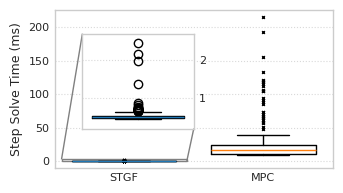

In [83]:
plot_droop = False
labels=('STGF', 'MPC', 'droop')
flier_props=dict(marker='x', markerfacecolor='black', markersize=2,
                  linestyle='none')

fig = plt.figure(figsize=(3.5, 2))

axs = []
axs.append(plt.subplot(1, 1, 1))
solve_time_data = [np.array(stgf_solve_times)*1000, np.array(mpc_solve_times)*1000,np.array(droop_solve_times)*1000]
positions = [0, 1, 2]
labels = ['STGF', 'MPC', 'droop']
if not plot_droop:
  solve_time_data.pop(2)
  positions.pop(2)
  labels.pop(2)

box_plot = plt.boxplot(solve_time_data,
                       tick_labels=labels, flierprops=flier_props, positions=positions, widths=0.75);
for i, median in enumerate(box_plot['medians']):
    median.set_color('C%s' % i)
# plt.boxplot(np.array(mpc_solve_times)*1000, tick_labels=1*('MPC',), flierprops=flier_props, positions=[1], widths=0.75);
# plt.boxplot(np.array(droop_solve_times)*1000, tick_labels=1*('droop',), flierprops=flier_props, positions=[2], widths=0.75);
plt.ylabel("Step Solve Time (ms)")

plt.tight_layout()

for ax in axs:
  ax.set_xlim(-0.5, len(box_plot['medians'])-0.5)
  ax.grid(axis='x')

axin_size = [0.17, 0.25, 0.2, 0.6]
if not plot_droop:
  axin_size = [0.1, 0.25, 0.4, 0.6]
axins = axs[0].inset_axes(axin_size)  # https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.inset_axes.html
axins.axis([-0.45, 0.45, np.min(stgf_solve_times)*1000 -np.max(stgf_solve_times)*1000*0.1, np.max(stgf_solve_times)*1000*1.1])
axins.yaxis.tick_right()
axins.grid(axis='x')
boxplot_stgf = axins.boxplot(np.array(stgf_solve_times)*1000, tick_labels=[''], positions=[0], widths=0.75)
boxplot_stgf['medians'][0].set_color('C0')
mark_inset(axs[0], axins, loc1=2, loc2=4, fc="none", ec="0.5")  # Draw connecting lines

if plot_droop:
  axins2 = axs[0].inset_axes([0.65, 0.25, 0.2, 0.6])
  axins2.axis([1.55, 2.45, np.min(droop_solve_times)*1000 - np.max(droop_solve_times)*1000*0.1, np.max(droop_solve_times)*1000*1.1])
  boxplot_droop = axins2.boxplot(np.array(droop_solve_times)*1000, tick_labels=[''], positions=[2], widths=0.75)
  boxplot_droop['medians'][0].set_color('C2')
  axins.grid(axis='x')
  mark_inset(axs[0], axins2, loc1=1, loc2=3, fc="none", ec="0.5")  # Draw connecting lines

plt.xlim(-0.5, len(box_plot['medians'])-0.5)

""" Code for saving plots as an .eps file """
fname="runtime-boxplot.pdf"
plt.savefig(fname, dpi=300, format=None, metadata=None,
        bbox_inches='tight', pad_inches=0.0,
        facecolor='auto', edgecolor='auto',
        backend=None
       );

## Animation of STGF Trajectory

In [84]:
animate_trajectory = True

Time slow-down:  75.0 x
Frame 1 / 150, i: 100
Frame 1 / 150, i: 100
Frame 2 / 150, i: 100
Frame 3 / 150, i: 102
Frame 4 / 150, i: 102
Frame 5 / 150, i: 104
Frame 6 / 150, i: 104
Frame 7 / 150, i: 106
Frame 8 / 150, i: 106
Frame 9 / 150, i: 108
Frame 10 / 150, i: 108
Frame 11 / 150, i: 110
Frame 12 / 150, i: 110
Frame 13 / 150, i: 112
Frame 14 / 150, i: 112
Frame 15 / 150, i: 114
Frame 16 / 150, i: 114
Frame 17 / 150, i: 116
Frame 18 / 150, i: 116
Frame 19 / 150, i: 118
Frame 20 / 150, i: 118
Frame 21 / 150, i: 120
Frame 22 / 150, i: 120
Frame 23 / 150, i: 122
Frame 24 / 150, i: 122
Frame 25 / 150, i: 124
Frame 26 / 150, i: 124
Frame 27 / 150, i: 126
Frame 28 / 150, i: 126
Frame 29 / 150, i: 128
Frame 30 / 150, i: 128
Frame 31 / 150, i: 130
Frame 32 / 150, i: 130
Frame 33 / 150, i: 132
Frame 34 / 150, i: 132
Frame 35 / 150, i: 134
Frame 36 / 150, i: 134
Frame 37 / 150, i: 136
Frame 38 / 150, i: 136
Frame 39 / 150, i: 138
Frame 40 / 150, i: 138
Frame 41 / 150, i: 140
Frame 42 / 150, i: 1

<Figure size 400x400 with 0 Axes>

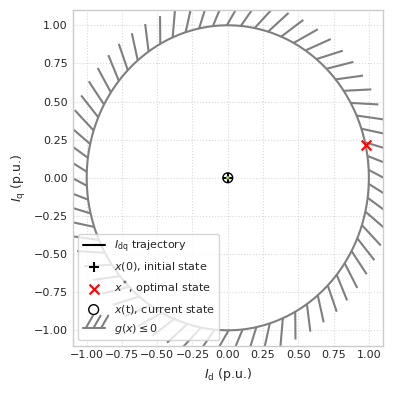

In [85]:
# Create an animation
if animate_trajectory:
  from matplotlib.animation import FuncAnimation
  from matplotlib import cm

  figsize = (4,4)
  ax_scale = 1.1

  # Step 4: Generate GIF Using Matplotlib
  fig = plt.figure(figsize=figsize)


  step_indx = T_sim//4

  def create_plot(frame_number, xs, xs_preopt, plt_to_i, start_i, fig, num_frames, plot_perc=1.0):
    plt.clf()  # Clear the current figure

    fig = plt.figure(figsize=figsize) if fig is None else fig

    # Plot Id versus Iq to visualize the trajectories
    #plt_to_i = 400  # End gif at simulation data index i
    #start_i = 100  # Start gif at simulation data index i

    markevery = 4

    traj_len = int(round(plt_to_i * plot_perc))
    frame_step = (plt_to_i - start_i) // (num_frames // (n_iters + 1))
    i = frame_step * (frame_number // (n_iters + 1))  + start_i  # Only step i every 2 frames
    print("Frame %s / %s, i: %s" % (frame_number+1, num_frames, i))

    # Plot frame here
    # if frame_number % 2 == 1:  #TODO: Determine if this should be == 0 or == 1
    #   #TODO: +frame step or +1 below.
    #   traj_line = plt.plot(xs[start_i:i+1, 0, 0], xs[start_i:i+1, 1, 0], lw=1.5, color='k', zorder=3, marker='.', markevery=5);
    # else:
    #   traj_line = plt.plot(xs[start_i:i, 0, 0], xs[start_i:i, 1, 0], lw=1.5, color='k', zorder=3, marker='.', markevery=5);
    traj_line = plt.plot(xs[start_i:i+1, 0], xs[start_i:i+1, 1], lw=1.5, color='k', zorder=5, marker='', markevery=markevery);#, mfc='none', mec='k');
    traj_markers = plt.scatter(xs[start_i:i-(0):markevery, 0], xs[start_i:i-(0):markevery, 1], color='k', zorder=6, marker='.')  # mark up until final point
    y_domain, x_domain = (-2, 2), (-2, 2)
    contour = plot_2d_constraints(gx[0, :], Matrix(xt[:2, 1]), y_domain, x_domain);
    x0_mark = plt.scatter(xs[0, 0], xs[0, 1], marker='+', color='k',s=50)
    xf_mark = plt.scatter(x_opt[0], x_opt[1], marker='x', color='r',s=50, zorder=7)
    xl_mark = plt.scatter(xs[i, 0], xs[i, 1], marker='o', facecolor='none', edgecolor='k',s=50, zorder=8)

    import matplotlib.lines as mlines
    c_line = mlines.Line2D([], [], color='C7',
                              markersize=20, label='Blue stars')
    c_line.set(path_effects=[patheffects.withTickedStroke(angle=60, length=2, spacing=5.)])

    plt.legend([traj_line[0], x0_mark, xf_mark, xl_mark, c_line],
    [r"$I_\mathrm{dq}$ trajectory", r"$x(0)$, initial state", r"$x^*$, optimal state", r"$x(\mathrm{t})$, current state", r"$g(x) \leq 0$"],
              loc="lower left", frameon=True)

    # Plot trajectory prediction horizon
    # if j % 2 == 1:  # Plot rolled pre-optimization step trajectory
    #   for k in range(T-2):
    #     color=cm.hot(k/T)
    #     plt.plot(xs[i, n*k:n*(k+1)+1:n, :], xs[i, 1+(n*k):(n*(k+1))+2:n, :], marker='', markersize=7, markevery=4, alpha=0.7, color=color, zorder=1)
    #   #plt.plot(xs[i, 0:T*n:n, :], xs[i, 1:T*n+1:n, :], marker='.', markersize=7, markevery=4, alpha=0.7, color='k', zorder=1)
    #   plt.scatter(xs[i, 0:T*n:4*n, :], xs[i, 1:T*n+1:4*n, :], marker='.', s=7, alpha=0.7, c=cm.hot(np.arange(T/4)/T), zorder=1)
    # else:
    colormap = cm.viridis(0.1 + 0.8 *(np.arange(T/markevery)/(T//markevery)))
    j = frame_number % (n_iters+1)
    for k in range(0, T-1):
      color=colormap[k//markevery]
      plt.plot(xs_preopt[i, n*k:n*(k+1)+1:n, j], xs_preopt[i, 1+(n*k):(n*(k+1))+2:n, j], marker='', markersize=7, markevery=markevery, alpha=0.7, color=color, zorder=3)
    #plt.plot(xs[i, 0:T*n:n, :], xs[i, 1:T*n+1:n, :], marker='.', markersize=7, markevery=4, alpha=0.7, color='k', zorder=1)
    plt.scatter(xs_preopt[i, 0:T*n:markevery*n, j], xs_preopt[i, 1:T*n+1:markevery*n, j], marker='.', s=7, alpha=0.7, c=colormap, zorder=4)

    plt.xlabel(r"$I_\mathrm{d}$ (p.u.)")
    plt.ylabel(r"$I_\mathrm{q}$ (p.u.)")

    # plt.ylim(-0.6, 0.1);
    # plt.xlim(-0.1, 1.1);

    plt.ylim(-1.1, 1.1);
    plt.xlim(-1.1, 1.1);

    plt.title('')

    plt.tight_layout()

  # Animation function
  def animate(frame_number, xs, xs_preopt, plt_to_i, start_i, figure=None, num_frames=10):
      create_plot(frame_number, xs, xs_preopt, plt_to_i, start_i, figure, num_frames)

  plot_to_i = 250 #400
  start_i = step_time
  num_frames = (plot_to_i - start_i)*n_iters #int(200 * 30/25)
  frame_interval = 150 #500
  data_time = T_sim * dt
  print("Time slow-down: ", (frame_interval/1000 * num_frames) / data_time, 'x')
  animation = FuncAnimation(fig, animate, frames=num_frames, interval=frame_interval, fargs=[xs_sim, xus_preopt, plot_to_i, start_i, fig, num_frames], repeat_delay=2000)
  file_name = 'stgf_trajectory.gif'
  animation.save(file_name, writer='pillow', dpi=200)  # Use 'pillow' writer for GIFs

  # Test animate create_plot function
  create_plot(20, xs_sim, xus_preopt, plot_to_i, start_i, None, num_frames, plot_perc=1.0)

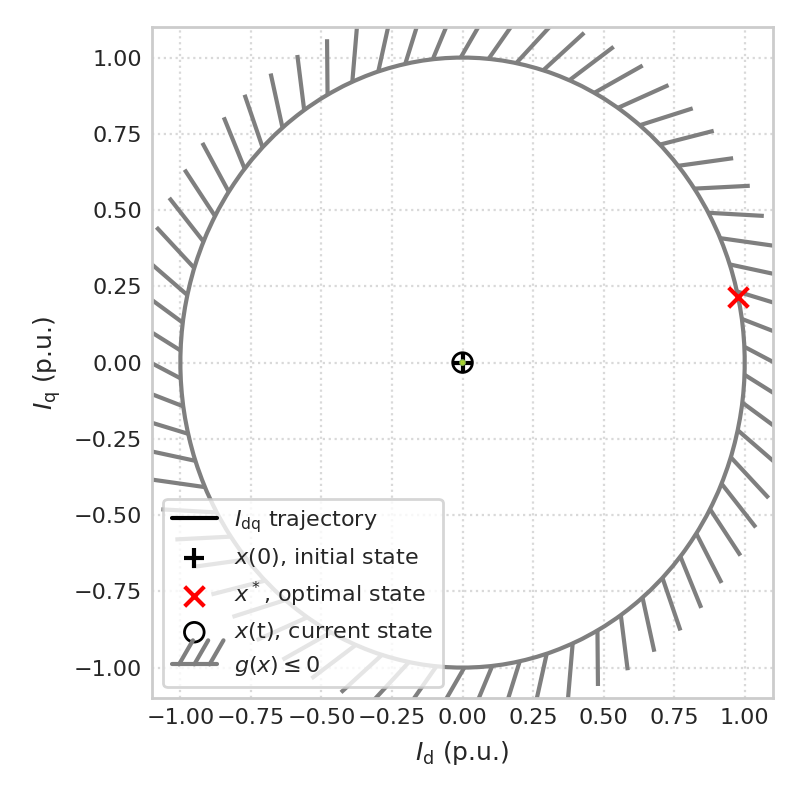

In [86]:
# Displays the animation if it was created (or the last saved plot)
from IPython.display import Image, display
Image(open(file_name,'rb').read())

In [87]:
### End of Notebook ###